# Cacao flower microbiome — clustermap exploration

Hierarchical clustering of 16S and ITS1 amplicon data across 4 datasets:
- **16S all** / **16S bio**: bacterial communities
- **ITS1 all** / **ITS1 bio**: fungal communities

Sections:
1. Data loading (single cell for all 4 datasets)
2. Colour palettes (short = 4 strips; long = + microscopy variables)
3. 16S all-samples: individual clustermap figures
4. Comparative 4-panel figures (all datasets)
5. Filtered ASVs: Aitchison clustermap after prevalence/abundance filtering

In [53]:
from pathlib import Path
import colorsys

import biom
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from skbio.stats.composition import clr
from skbio.stats.distance import DistanceMatrix, permanova
from matplotlib import gridspec as mgs


## Paths

In [54]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR     = PROJECT_ROOT / "results" / "biom"
METADATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR    :", DATA_DIR)
print("METADATA_DIR:", METADATA_DIR)

PROJECT_ROOT: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome
DATA_DIR    : /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/biom
METADATA_DIR: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/data


## Data loading

All four feature tables, their taxonomies, and the sample metadata are loaded **once** here. Downstream cells reference `RAW[key]` dicts and `metadata_raw`.

In [55]:
# ── BIOM file specs ──────────────────────────────────────────────────────────
_BIOM_SPECS = [
    ('16s_all',  'cfm_16s_bacteria_allsamples_feature-table.biom',
                 'cfm_16s_bacteria_allsamples_taxonomy.tsv'),
    ('16s_bio',  'cfm_16s_bacteria_biosamples_feature-table.biom',
                 'cfm_16s_bacteria_biosamples_taxonomy.tsv'),
    ('its1_all', 'cfm_its1_fungi_allsamples_feature-table.biom',
                 'cfm_its1_fungi_allsamples_taxonomy.tsv'),
    ('its1_bio', 'cfm_its1_fungi_biosamples_feature-table.biom',
                 'cfm_its1_fungi_biosamples_taxonomy.tsv'),
]

def extract_genus(taxon):
    for part in str(taxon).split(';'):
        p = part.strip()
        if p.startswith('g__'):
            g = p[3:].strip()
            return g if g else 'unclassified'
    return 'unclassified'

def multiplicative_replacement(mat, delta=None):
    mat = np.asarray(mat, dtype=float)
    n   = mat.shape[1]
    if delta is None:
        delta = 1.0 / n ** 2
    result = mat.copy()
    for i in range(len(result)):
        zm = result[i] == 0;  k = zm.sum()
        if k:
            result[i, zm]  = delta
            result[i, ~zm] *= 1.0 - k * delta
    return result

# ── Load all datasets ─────────────────────────────────────────────────────────
RAW = {}
for key, bf, tf in _BIOM_SPECS:
    tbl  = biom.load_table(str(DATA_DIR / bf))
    sids = list(tbl.ids(axis='sample'))
    cnt  = pd.DataFrame(tbl.matrix_data.toarray().T, index=sids,
                        columns=list(tbl.ids(axis='observation')))
    nz = cnt.sum(axis=1) > 0
    if (~nz).any():
        cnt = cnt[nz];  sids = cnt.index.tolist()
    rel = cnt.div(cnt.sum(axis=1), axis=0)
    tax = pd.read_csv(str(DATA_DIR / tf), sep='\t', index_col=0)
    RAW[key] = dict(sids=sids, cnt=cnt, rel=rel, tax=tax)

# ── Metadata ─────────────────────────────────────────────────────────────────
metadata_raw = (
    pd.read_excel(METADATA_DIR / 'sample_metadata_with_microscopy.xlsx', index_col=0)
    .iloc[1:]
)
metadata_raw.index.name = 'sample_id'
_num_cols = ['dna_conc_hs_16s', 'dna_conc_hs_its1',
             'pi_dic', 'pi_clsm', 'callose_plug_index', 'fungal_colonization_score']
for col in _num_cols:
    if col in metadata_raw.columns:
        metadata_raw[col] = pd.to_numeric(metadata_raw[col], errors='coerce')

# Backward-compatible aliases (16S all-samples)
sample_ids   = RAW['16s_all']['sids']
rel_abund_df = RAW['16s_all']['rel']
asv_ids      = list(RAW['16s_all']['cnt'].columns)
n_asvs_total = len(asv_ids)
metadata     = metadata_raw.reindex(sample_ids)

# ── Summary output ────────────────────────────────────────────────────────────
print('Feature tables loaded:')
for key, bf, _ in _BIOM_SPECS:
    raw = RAW[key]
    meta_k = metadata_raw.reindex(raw['sids'])
    vc = meta_k['sample_type'].value_counts()
    vc_str = ', '.join(f"'{k}': {v}" for k, v in vc.items())
    print(f'  {key:12s}: {len(raw["sids"]):3d} samples x {raw["cnt"].shape[1]:6d} ASVs '
          f'| sample_type: {{{vc_str}}}')

print(f'\nMetadata: {metadata_raw.shape[0]} total rows, {metadata_raw.shape[1]} columns')
print('Column summary (non-NA count | type/unique):')
for col in metadata_raw.columns:
    n_ok = int(metadata_raw[col].notna().sum())
    if pd.api.types.is_numeric_dtype(metadata_raw[col]):
        v = metadata_raw[col].dropna()
        print(f'  {col:40s}  {n_ok:3d} non-NA  numeric  '
              f'[{v.min():.2g}, {v.max():.2g}]')
    else:
        n_u = int(metadata_raw[col].nunique())
        vals = sorted(metadata_raw[col].dropna().unique())[:5]
        print(f'  {col:40s}  {n_ok:3d} non-NA  {n_u:2d} unique  {vals}')


Feature tables loaded:
  16s_all     : 334 samples x  25035 ASVs | sample_type: {'bagged_flower': 147, 'unbagged_flower': 147, 'negative_pcr_control': 14, 'mock_community': 14, 'extraction_control': 12}
  16s_bio     : 294 samples x  25035 ASVs | sample_type: {'bagged_flower': 147, 'unbagged_flower': 147}
  its1_all    : 326 samples x  11929 ASVs | sample_type: {'bagged_flower': 147, 'unbagged_flower': 147, 'mock_community': 14, 'negative_pcr_control': 10, 'extraction_control': 8}
  its1_bio    : 294 samples x  11929 ASVs | sample_type: {'bagged_flower': 147, 'unbagged_flower': 147}

Metadata: 336 total rows, 32 columns
Column summary (non-NA count | type/unique):
  sublibrary_id                             336 non-NA  48 unique  ['A1_13A_13_12', 'A2_13A_13_02', 'A3_13A_13_03', 'A4_13A_13_04', 'A5_13A_19_08']
  sample_type                               336 non-NA   5 unique  ['bagged_flower', 'extraction_control', 'mock_community', 'negative_pcr_control', 'unbagged_flower']
  managemen

## Colour palettes

- **Short** (4 strips): `sample_type`, `management_type`, `farm_id`, `tree_id`
- **Long** (8 strips): + `fungal_colonization_score`, `is_germination`, `is_hyphae_present`, `callose_plug_index`

Helper functions `_row_colors4(meta)` and `make_row_colors_long(meta)` return a DataFrame of hex colors indexed by sample ID.

In [56]:
SAMPLE_TYPE_COLORS = {
    'bagged_flower':        '#4C72B0',
    'unbagged_flower':      '#DD8452',
    'extraction_control':   '#55A868',
    'negative_pcr_control': '#C44E52',
    'mock_community':       '#8172B2',
}
CTRL_COLOR = '#cccccc'

_BIO_ST   = ('bagged_flower', 'unbagged_flower')
_bio_mask = metadata_raw['sample_type'].isin(_BIO_ST)

farm_ids_uniq = sorted(metadata_raw.loc[_bio_mask, 'farm_id'].dropna().unique())
farm_palette  = dict(zip(farm_ids_uniq, sns.color_palette('Set2', len(farm_ids_uniq))))

def make_tree_palette(farm_ids_list, n_trees=7):
    pal = {}
    for i, farm in enumerate(farm_ids_list):
        hue = i / len(farm_ids_list)
        for t in range(1, n_trees + 1):
            l = 0.75 - 0.45 * (t - 1) / (n_trees - 1)
            r, g, b = colorsys.hls_to_rgb(hue, l, 0.72)
            pal[f'{farm}{t}'] = (r, g, b)
    return pal

tree_palette_49 = make_tree_palette(farm_ids_uniq)

_mgmt_bio   = sorted(metadata_raw.loc[_bio_mask, 'management_type'].dropna().unique())
MGMT_COLORS = dict(zip(_mgmt_bio, sns.color_palette('Paired', len(_mgmt_bio))))

# ── Categorical palettes for batch variables ──────────────────────────────────
def _make_cat_palette(col, cmap_name='tab10'):
    vals = sorted(metadata_raw[col].dropna().unique())
    colors = sns.color_palette(cmap_name, len(vals))
    return {v: mpl.colors.to_hex(c) for v, c in zip(vals, colors)}

BATCH_PALETTES = {
    'collection_batch': _make_cat_palette('collection_batch', 'tab10'),
    'extraction_batch': _make_cat_palette('extraction_batch', 'Set1'),
    'pcr_batch_16s':    _make_cat_palette('pcr_batch_16s',    'Paired'),
    'pcr_batch_its1':   _make_cat_palette('pcr_batch_its1',   'Set2'),
}

# ── Binary / ordinal palettes ─────────────────────────────────────────────────
BIN_COLOR  = {0: '#4393C3', 1: '#D6604D'}
FCS_COLORS = {0: '#F7F7F7', 1: '#FEE08B', 2: '#FDAE61',
              3: '#F46D43',  4: '#D73027',  5: '#B30000'}

def _get_color(v, palette):
    if pd.isna(v):
        return CTRL_COLOR
    key = int(v) if isinstance(v, float) and not pd.isna(v) and v == int(v) else v
    return palette.get(key, CTRL_COLOR)

# ── Short palette: 4 annotation strips ───────────────────────────────────────
def _row_colors4(meta):
    def _c(sid, col, pal):
        v = meta.loc[sid, col]
        return CTRL_COLOR if pd.isna(v) or v not in pal else pal[v]
    s = meta.index.tolist()
    return pd.DataFrame({
        'type': [SAMPLE_TYPE_COLORS.get(meta.loc[x, 'sample_type'], CTRL_COLOR) for x in s],
        'mgmt': [_c(x, 'management_type', MGMT_COLORS)  for x in s],
        'farm': [_c(x, 'farm_id',          farm_palette) for x in s],
        'tree': [_c(x, 'tree_id', tree_palette_49)       for x in s],
    }, index=s)

# ── Long palette: 4 + 8 microscopy/batch strips ───────────────────────────────
def make_row_colors_long(meta):
    s    = meta.index.tolist()
    base = _row_colors4(meta)
    ext  = pd.DataFrame({
        'pollination':   [_get_color(meta.loc[x, 'is_pollination_clsm'], BIN_COLOR)  for x in s],
        'germination':   [_get_color(meta.loc[x, 'is_germination'],      BIN_COLOR)  for x in s],
        'hyphae':        [_get_color(meta.loc[x, 'is_hyphae_present'],   BIN_COLOR)  for x in s],
        'FCS':           [_get_color(meta.loc[x, 'fungal_colonization_score'], FCS_COLORS) for x in s],
        'coll_batch':    [_get_color(meta.loc[x, 'collection_batch'],    BATCH_PALETTES['collection_batch']) for x in s],
        'extr_batch':    [_get_color(meta.loc[x, 'extraction_batch'],    BATCH_PALETTES['extraction_batch']) for x in s],
        'pcr_16s':       [_get_color(meta.loc[x, 'pcr_batch_16s'],       BATCH_PALETTES['pcr_batch_16s'])    for x in s],
        'pcr_its1':      [_get_color(meta.loc[x, 'pcr_batch_its1'],      BATCH_PALETTES['pcr_batch_its1'])   for x in s],
    }, index=s)
    return pd.concat([base, ext], axis=1)

# ── 16S all-samples annotation (backward compat) ──────────────────────────────
row_colors_all = _row_colors4(metadata)

# ── Legend helpers ────────────────────────────────────────────────────────────
_leg_stype = [Patch(facecolor=c, label=n, lw=0) for n, c in SAMPLE_TYPE_COLORS.items()]
_leg_mgmt  = [Patch(facecolor=mpl.colors.to_hex(c), label=n, lw=0)
              for n, c in MGMT_COLORS.items()]
_leg_farm  = [Patch(facecolor=mpl.colors.to_hex(c), label=f, lw=0)
              for f, c in farm_palette.items()]
_leg_tree  = [Patch(facecolor=mpl.colors.to_hex(tree_palette_49.get(f'{fm}{t}', CTRL_COLOR)),
                    label=f'{fm}{t}', lw=0)
              for fm in farm_ids_uniq for t in range(1, 8)]

_LEG_KW = dict(loc='upper center', fontsize=9, title_fontsize=10,
               framealpha=0.9, borderaxespad=0,
               columnspacing=1.0, handlelength=1.2, handletextpad=0.5)

def add_legends(fig, y0=0.965, dy=0.030):
    kw = dict(_LEG_KW, bbox_transform=fig.transFigure)
    fig.legend(handles=_leg_stype, title='sample type',
               bbox_to_anchor=(0.5, y0),        ncol=len(SAMPLE_TYPE_COLORS), **kw)
    fig.legend(handles=_leg_mgmt,  title='management',
               bbox_to_anchor=(0.5, y0 - dy),   ncol=len(MGMT_COLORS),       **kw)
    fig.legend(handles=_leg_farm,  title='farm',
               bbox_to_anchor=(0.5, y0 - 2*dy), ncol=len(farm_palette),       **kw)
    fig.legend(handles=_leg_tree,  title='tree (farm+#)',
               bbox_to_anchor=(0.5, y0 - 3*dy), ncol=7,                       **kw)

def add_cbar(fig, cmap, norm, label, pos=(0.02, 0.755, 0.18, 0.006)):
    cax = fig.add_axes(list(pos))
    cb  = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                       cax=cax, orientation='horizontal')
    cb.set_label(label, fontsize=10);  cb.ax.tick_params(labelsize=9)
    return cb

print('Palettes ready.')
print(f'  Short strips: {list(row_colors_all.columns)}')
print(f'  Long  strips: {list(make_row_colors_long(metadata).columns)}')
for k, v in BATCH_PALETTES.items():
    print(f'  {k}: {list(v.keys())}')


Palettes ready.
  Short strips: ['type', 'mgmt', 'farm', 'tree']
  Long  strips: ['type', 'mgmt', 'farm', 'tree', 'pollination', 'germination', 'hyphae', 'FCS', 'coll_batch', 'extr_batch', 'pcr_16s', 'pcr_its1']
  collection_batch: [datetime.datetime(2023, 12, 14, 0, 0), datetime.datetime(2023, 12, 15, 0, 0)]
  extraction_batch: [datetime.datetime(2024, 9, 20, 0, 0), datetime.datetime(2024, 10, 1, 0, 0), datetime.datetime(2024, 10, 3, 0, 0), datetime.datetime(2024, 10, 6, 0, 0), datetime.datetime(2024, 10, 8, 0, 0), datetime.datetime(2024, 10, 13, 0, 0), datetime.datetime(2024, 10, 15, 0, 0), datetime.datetime(2024, 10, 17, 0, 0), datetime.datetime(2024, 10, 22, 0, 0), datetime.datetime(2024, 10, 23, 0, 0), datetime.datetime(2024, 10, 25, 0, 0), datetime.datetime(2024, 10, 27, 0, 0), datetime.datetime(2024, 10, 28, 0, 0), datetime.datetime(2024, 10, 30, 0, 0), datetime.datetime(2024, 11, 1, 0, 0)]
  pcr_batch_16s: [datetime.datetime(2024, 10, 14, 0, 0), datetime.datetime(2024, 10, 24, 

## Distance matrices: BC and Aitchison

BC         mean=0.8856  range=[0.0095, 1.0000]
Aitchison  mean=239.2730  range=[17.8139, 580.3703]


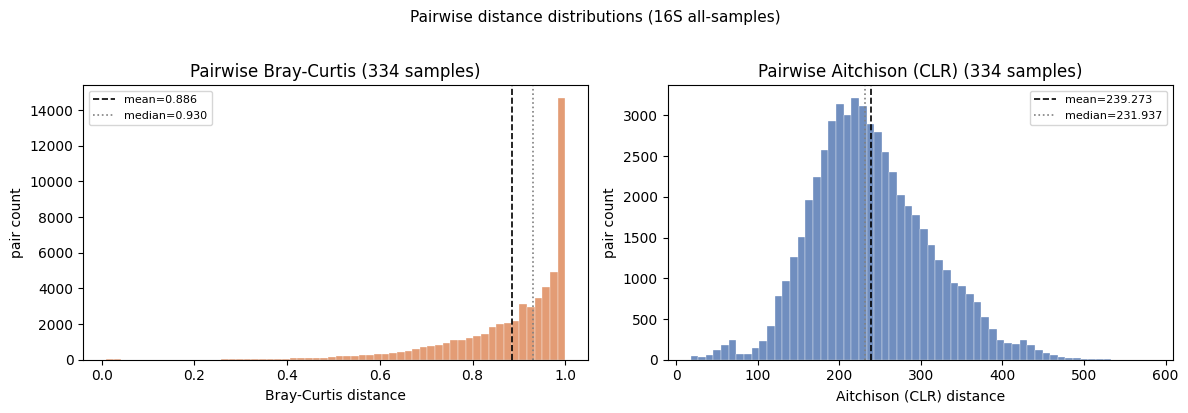

In [57]:
# ── Bray-Curtis (16S all-samples) ────────────────────────────────────────────
bc_condensed = pdist(rel_abund_df.values, metric='braycurtis')
bc_matrix    = squareform(bc_condensed)
bc_df        = pd.DataFrame(bc_matrix, index=sample_ids, columns=sample_ids)
bc_linkage   = linkage(bc_condensed, method='average')

# ── CLR + Aitchison ───────────────────────────────────────────────────────────
comp                = multiplicative_replacement(rel_abund_df.values)
clr_matrix          = clr(comp)
aitchison_condensed = pdist(clr_matrix, metric='euclidean')
aitchison_matrix    = squareform(aitchison_condensed)
aitchison_df        = pd.DataFrame(aitchison_matrix, index=sample_ids, columns=sample_ids)
aitchison_linkage   = linkage(aitchison_condensed, method='average')

triu_bc  = bc_matrix[np.triu_indices_from(bc_matrix, k=1)]
triu_ait = aitchison_matrix[np.triu_indices_from(aitchison_matrix, k=1)]

print(f'BC         mean={triu_bc.mean():.4f}  range=[{triu_bc.min():.4f}, {triu_bc.max():.4f}]')
print(f'Aitchison  mean={triu_ait.mean():.4f}  range=[{triu_ait.min():.4f}, {triu_ait.max():.4f}]')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, label, color in [
    (axes[0], triu_bc,  'Bray-Curtis',     '#DD8452'),
    (axes[1], triu_ait, 'Aitchison (CLR)', '#4C72B0'),
]:
    ax.hist(vals, bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.mean(),     color='black', ls='--', lw=1.2, label=f'mean={vals.mean():.3f}')
    ax.axvline(np.median(vals), color='grey',  ls=':',  lw=1.2, label=f'median={np.median(vals):.3f}')
    ax.set_xlabel(f'{label} distance');  ax.set_ylabel('pair count')
    ax.set_title(f'Pairwise {label} ({len(sample_ids)} samples)');  ax.legend(fontsize=8)
plt.suptitle('Pairwise distance distributions (16S all-samples)', y=1.02, fontsize=11)
plt.tight_layout();  plt.show()


### 16S all-samples: taxonomy labels and top-50 ASVs

In [80]:
N_TOP = 50
asv_to_genus_16s = RAW['16s_all']['tax']['Taxon'].apply(extract_genus).to_dict()
top_asvs  = rel_abund_df.mean(axis=0).nlargest(N_TOP).index
_cnt_tax: dict = {}
genus_raw    = [asv_to_genus_16s.get(a, 'unclassified') for a in top_asvs]
final_rename = {}
for asv, g in zip(top_asvs, genus_raw):
    if genus_raw.count(g) > 1:
        _cnt_tax[g] = _cnt_tax.get(g, 0) + 1
        final_rename[asv] = f'{g} ({_cnt_tax[g]})'
    else:
        final_rename[asv] = g
print(f'Top-{N_TOP} ASVs selected. Genera: {len(set(genus_raw))} unique.')


Top-50 ASVs selected. Genera: 23 unique.


## Relative abundance heatmap (top-50 ASVs)

Values: log₁₀(RA + 1e-6). Clustering: Euclidean distance, average linkage.

/home/nmmak/miniforge3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nmmak/miniforge3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


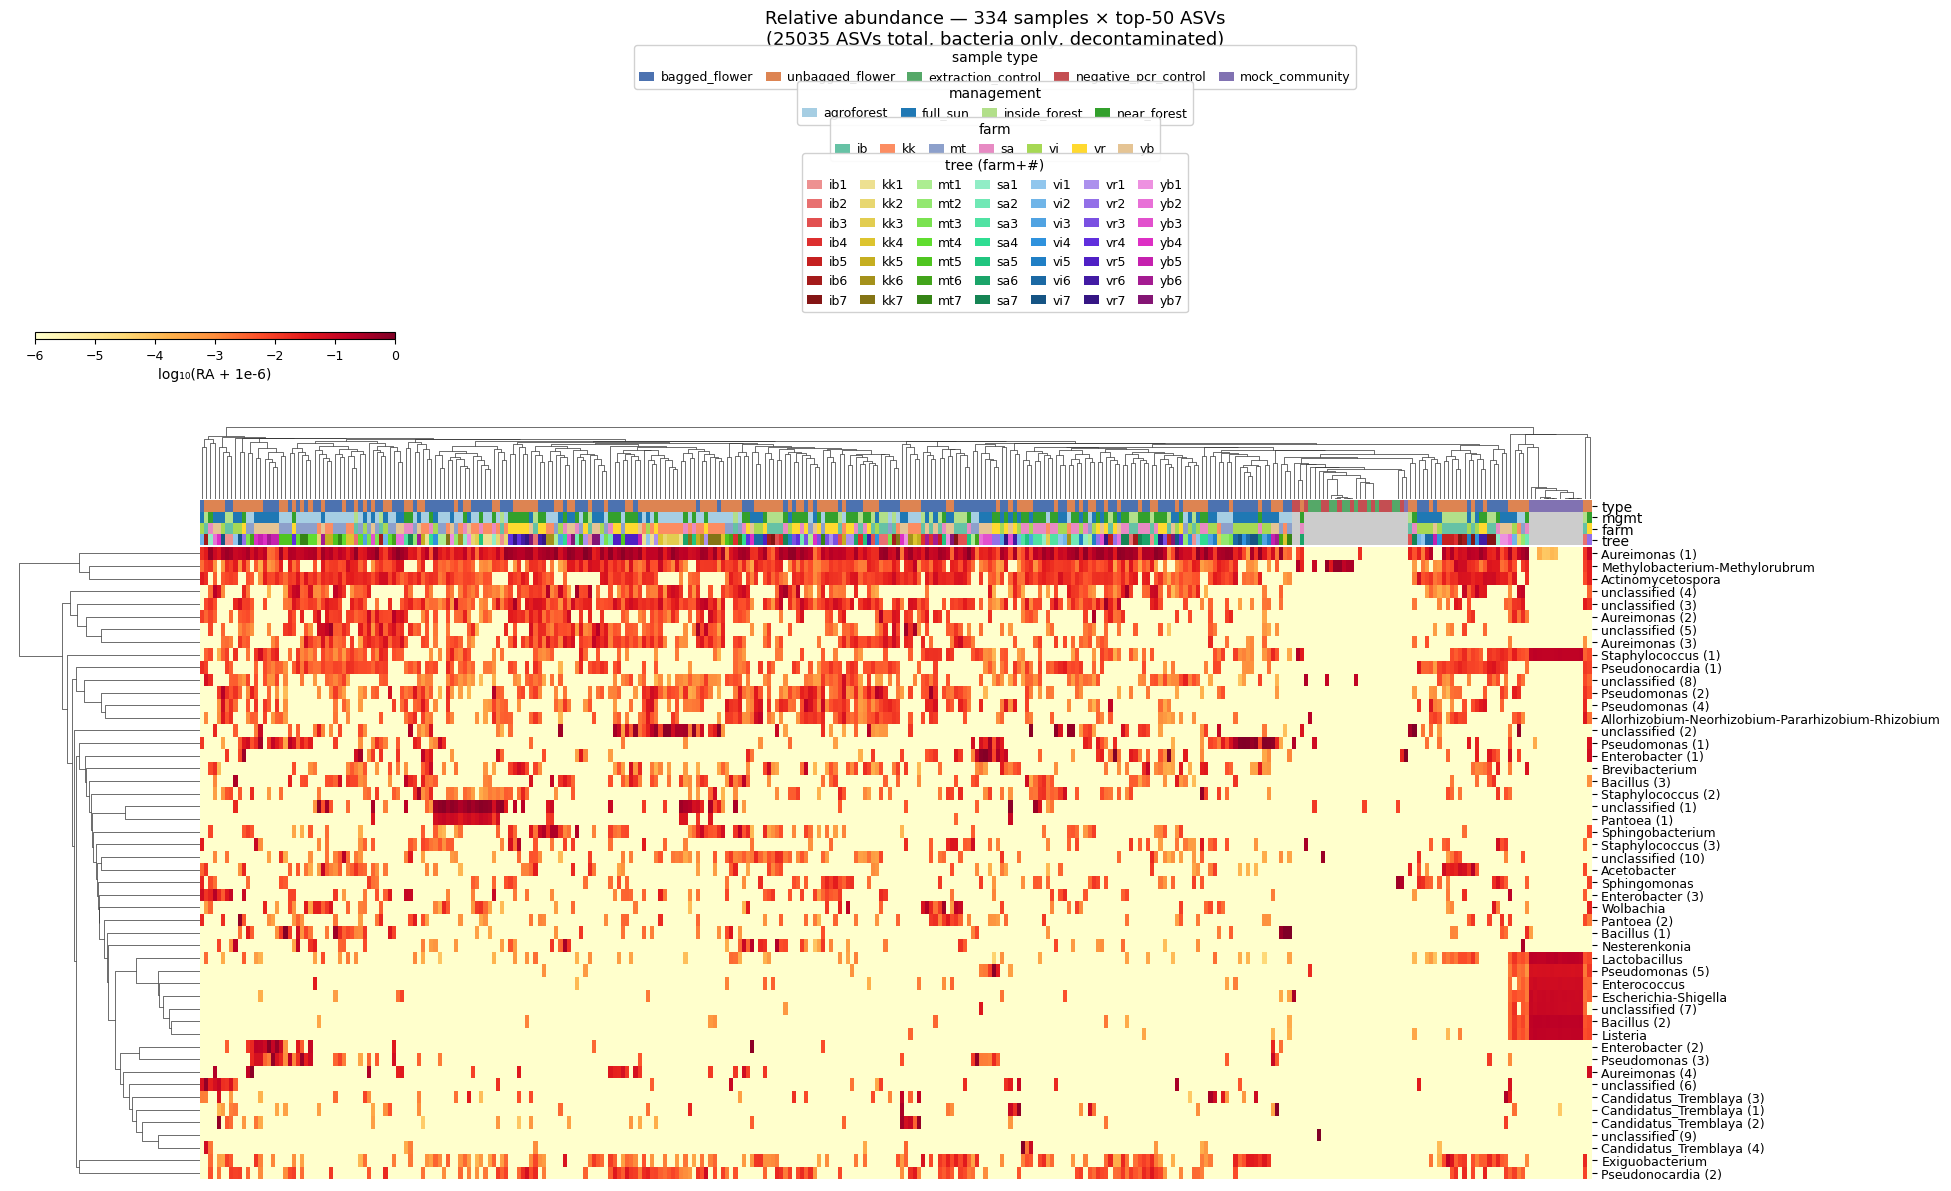

In [81]:
# Transpose: rows=ASVs (Y axis, horizontal labels), cols=samples (annotation at top)
plot_log_T = np.log10(rel_abund_df[top_asvs] + 1e-6).rename(columns=final_rename).T

g_ra = sns.clustermap(
    plot_log_T, method='average', metric='euclidean',
    col_colors=row_colors_all,   # 4-strip sample annotation at top
    figsize=(20, 12), yticklabels=True, xticklabels=False,
    cmap='YlOrRd', cbar_pos=None,
    dendrogram_ratio=(0.12, 0.10), colors_ratio=0.015,
)
g_ra.ax_heatmap.set_yticklabels(
    g_ra.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
g_ra.fig.subplots_adjust(bottom=0.02, top=0.65)
add_cbar(g_ra.fig, 'YlOrRd',
         mpl.colors.Normalize(vmin=plot_log_T.values.min(),
                               vmax=plot_log_T.values.max()),
         'log\u2081\u2080(RA + 1e-6)', pos=(0.02, 0.72, 0.18, 0.006))
g_ra.fig.suptitle(
    f'Relative abundance \u2014 {len(sample_ids)} samples \u00d7 top-{N_TOP} ASVs\n'
    f'({n_asvs_total} ASVs total, bacteria only, decontaminated)',
    x=0.5, y=0.995, ha='center', fontsize=13)
add_legends(g_ra.fig, y0=0.965, dy=0.030)
plt.show()


## CLR-transformed abundance heatmap

Same top-50 ASVs, CLR-transformed. **Red** = above geometric mean, **blue** = below.  
Row order: Aitchison linkage. ASV columns: re-clustered on CLR values.

/home/nmmak/miniforge3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


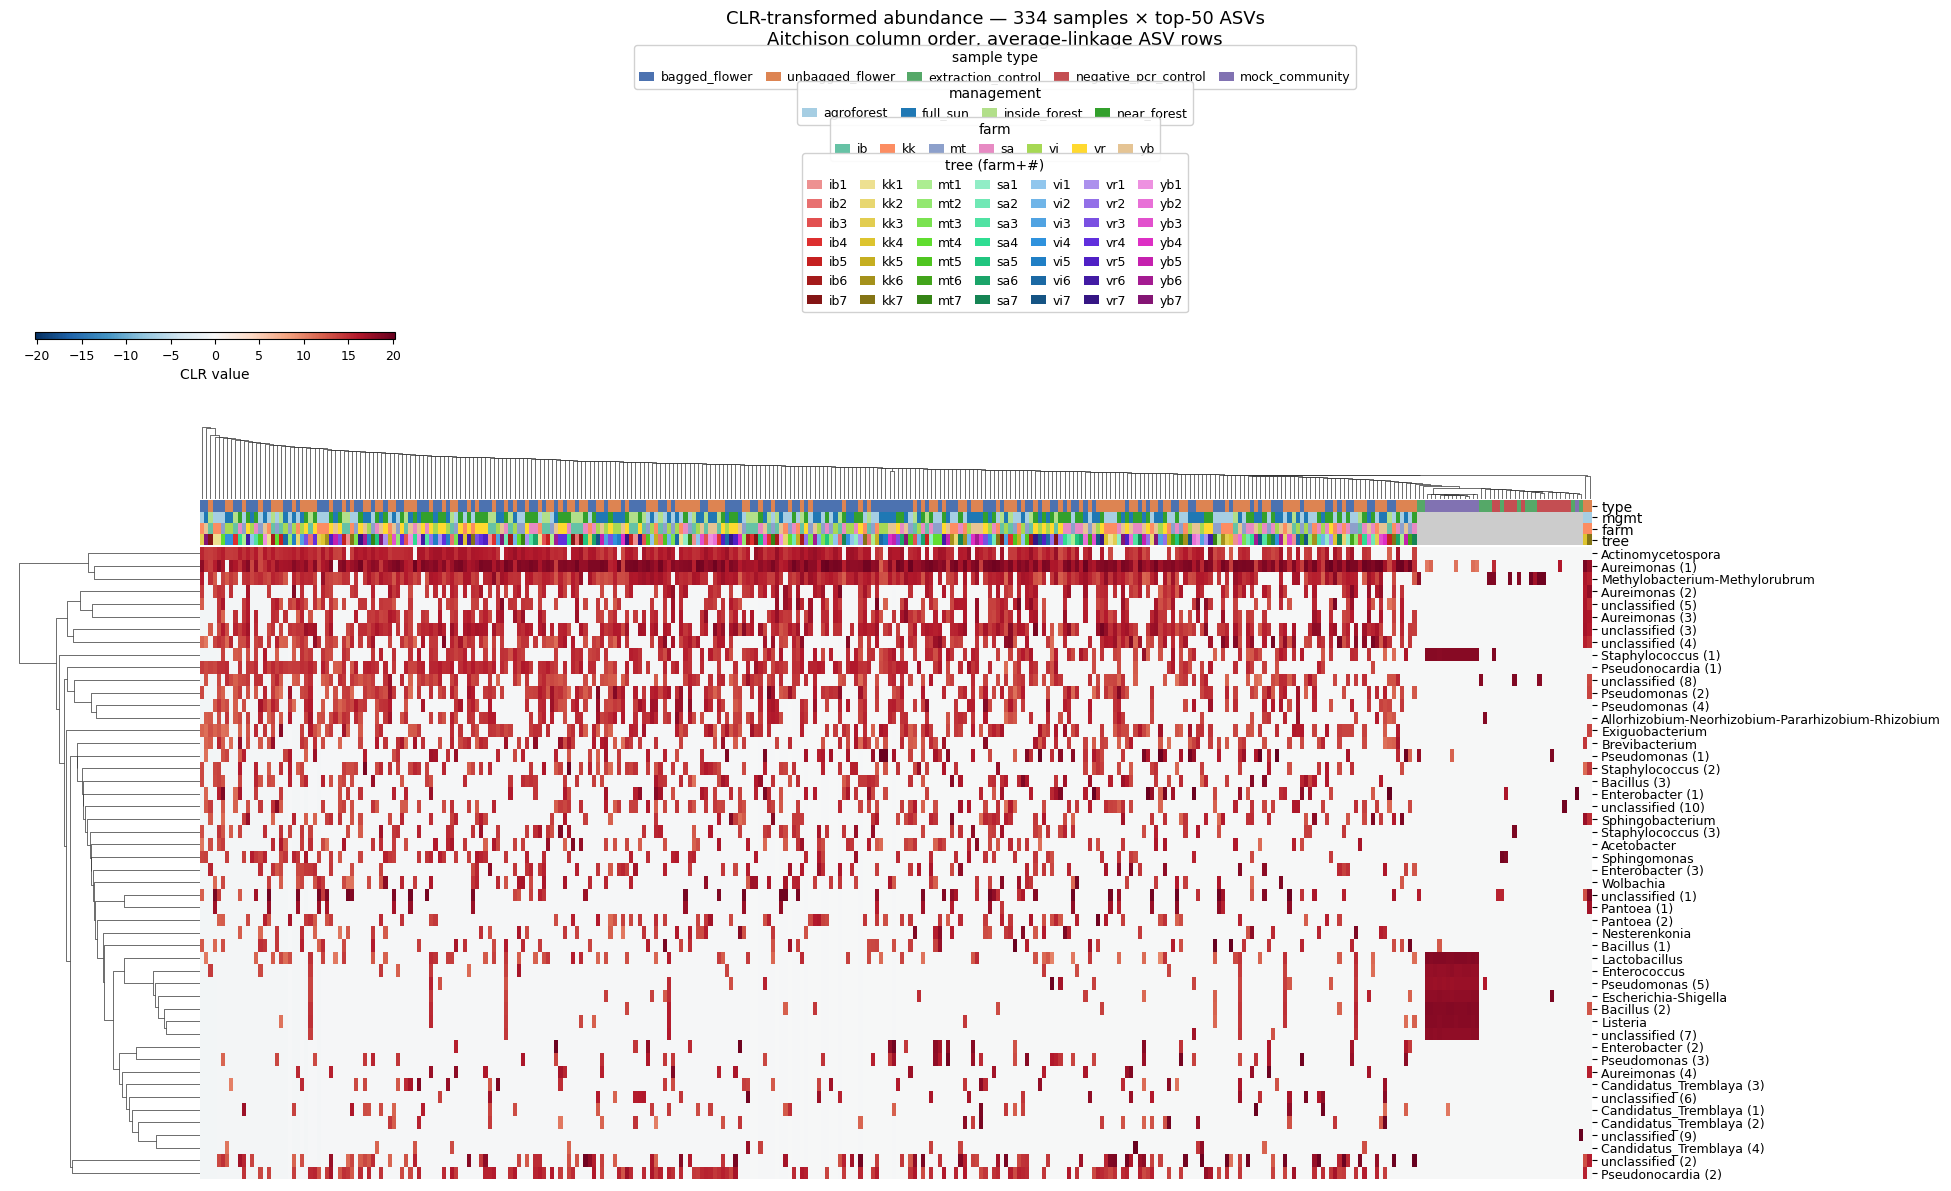

In [82]:
# Transpose: rows=ASVs (Y, horizontal), cols=samples (annotation at top)
clr_df    = pd.DataFrame(clr_matrix, index=sample_ids, columns=asv_ids)
clr_top50 = clr_df[top_asvs].rename(columns=final_rename)
clr_top50_T = clr_top50.T   # ASVs x samples

g_clr = sns.clustermap(
    clr_top50_T, col_linkage=aitchison_linkage,
    method='average', metric='euclidean',
    col_colors=row_colors_all,
    figsize=(20, 12), yticklabels=True, xticklabels=False,
    cmap='RdBu_r', center=0, cbar_pos=None,
    dendrogram_ratio=(0.12, 0.10), colors_ratio=0.015,
)
g_clr.ax_heatmap.set_yticklabels(
    g_clr.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
g_clr.fig.subplots_adjust(bottom=0.02, top=0.65)
vmax = max(abs(clr_top50_T.values.min()), abs(clr_top50_T.values.max()))
add_cbar(g_clr.fig, 'RdBu_r',
         mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
         'CLR value', pos=(0.02, 0.72, 0.18, 0.006))
g_clr.fig.suptitle(
    f'CLR-transformed abundance \u2014 {len(sample_ids)} samples \u00d7 top-{N_TOP} ASVs\n'
    'Aitchison column order, average-linkage ASV rows',
    x=0.5, y=0.995, ha='center', fontsize=13)
add_legends(g_clr.fig, y0=0.965, dy=0.030)
plt.show()


## Bray-Curtis dissimilarity matrix

All samples, average linkage on precomputed distances.

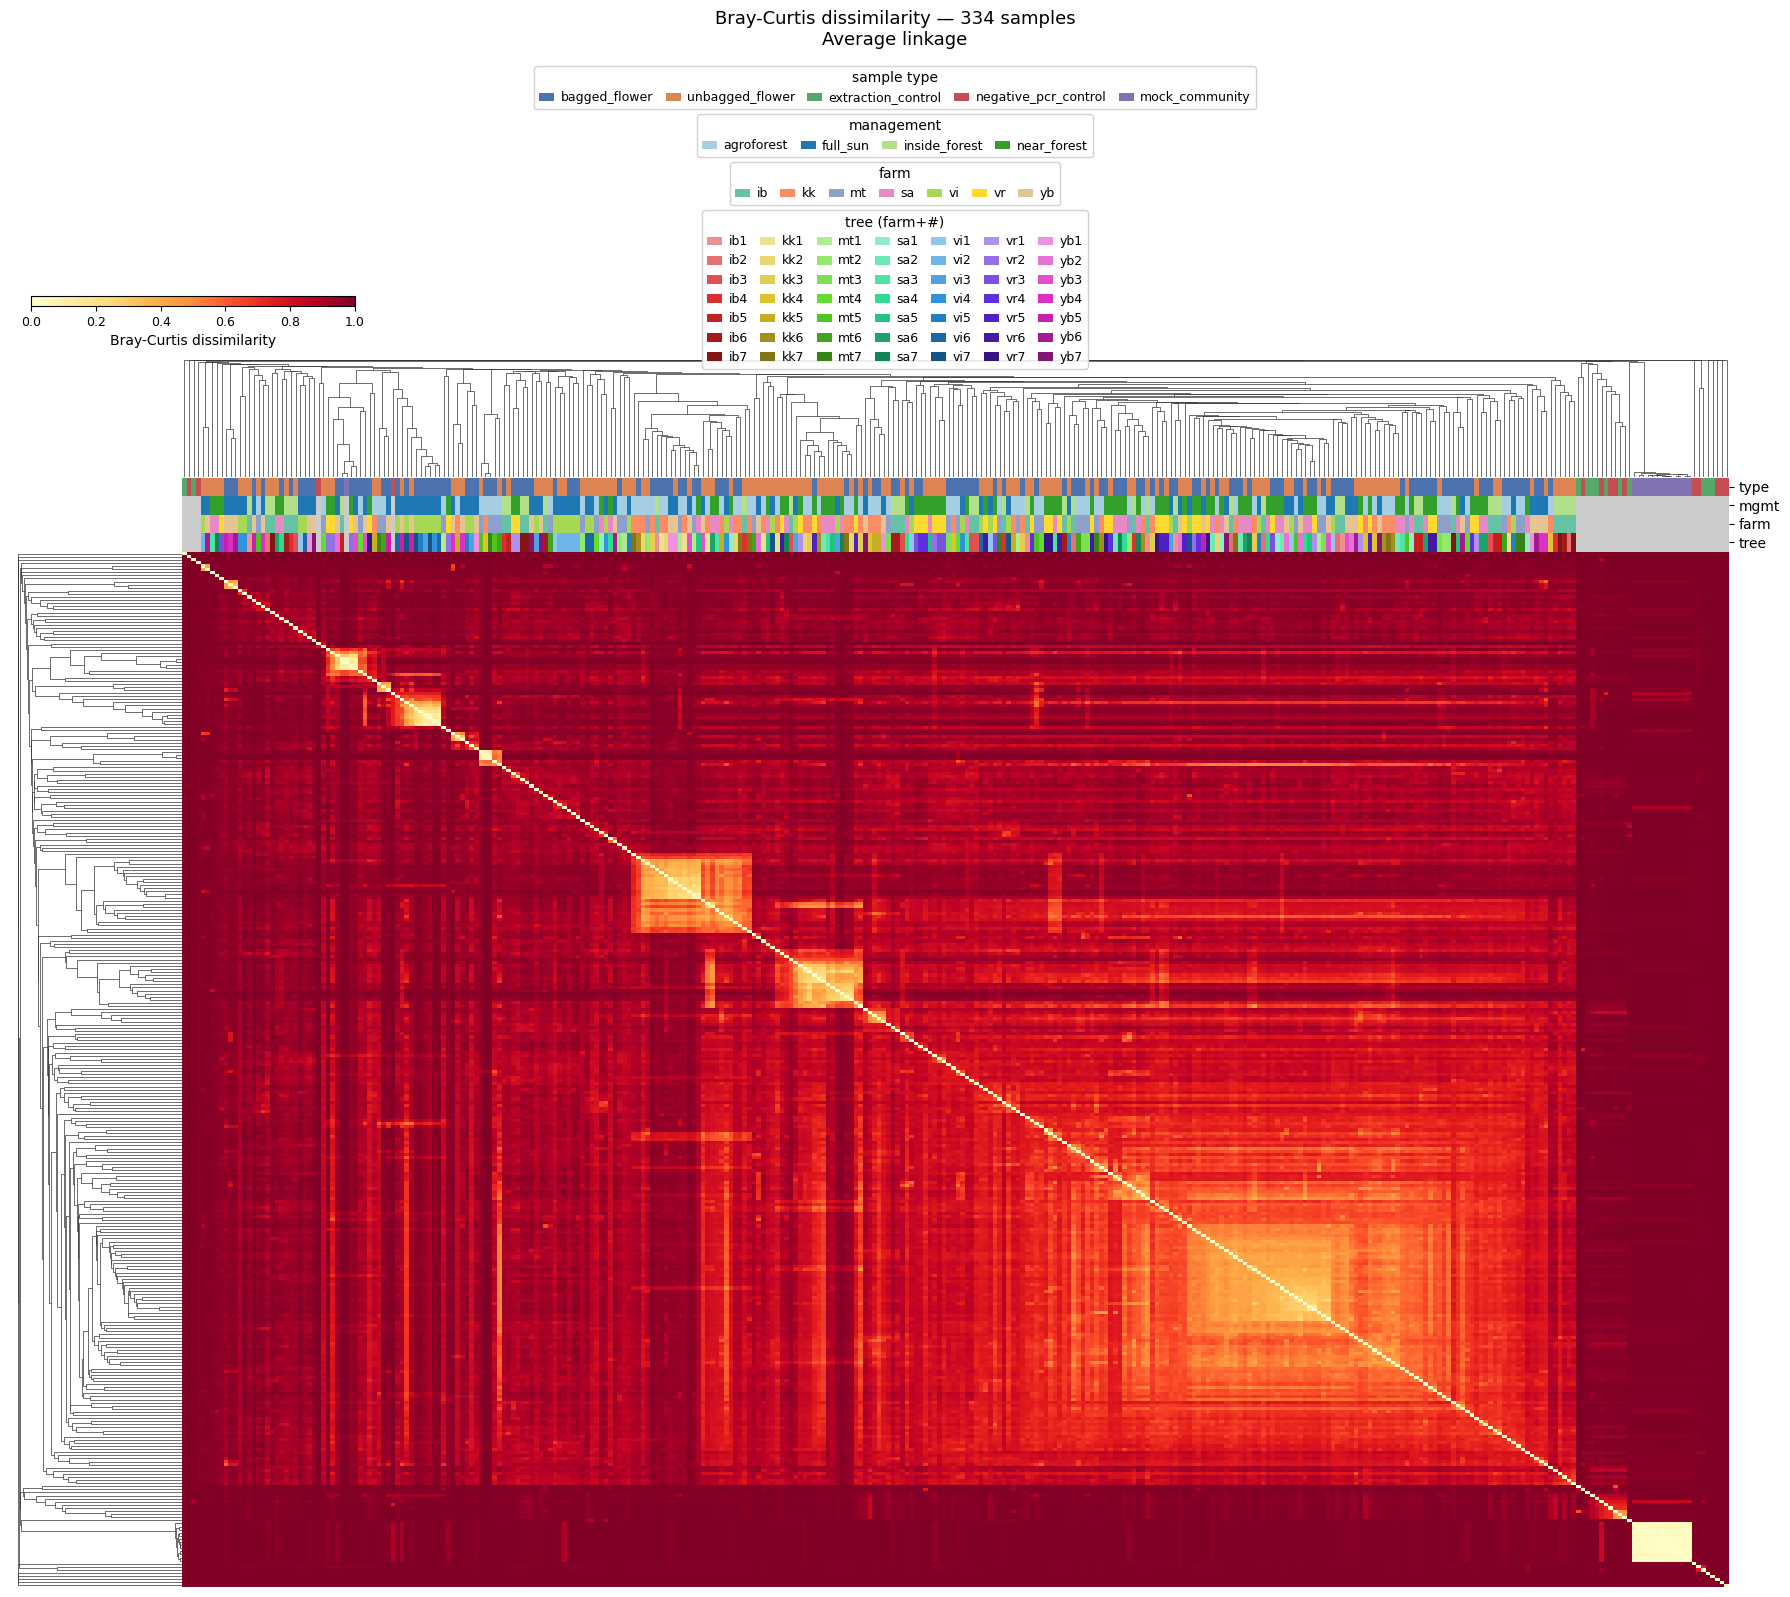

In [83]:
g_bc = sns.clustermap(
    bc_df, row_linkage=bc_linkage, col_linkage=bc_linkage,
    col_colors=row_colors_all,
    figsize=(18, 16), yticklabels=False, xticklabels=False,
    cmap='YlOrRd', cbar_pos=None, vmin=0, vmax=1,
    dendrogram_ratio=(0.10, 0.10), colors_ratio=0.015,
)
g_bc.fig.subplots_adjust(top=0.78)
add_cbar(g_bc.fig, 'YlOrRd', mpl.colors.Normalize(0, 1),
         'Bray-Curtis dissimilarity', pos=(0.02, 0.81, 0.18, 0.006))
g_bc.fig.suptitle(
    f'Bray-Curtis dissimilarity \u2014 {len(sample_ids)} samples\nAverage linkage',
    x=0.5, y=0.995, ha='center', fontsize=13)
add_legends(g_bc.fig, y0=0.960)
plt.show()


## Aitchison distance matrix

Euclidean distance on CLR-transformed compositions. Zeros: multiplicative replacement.

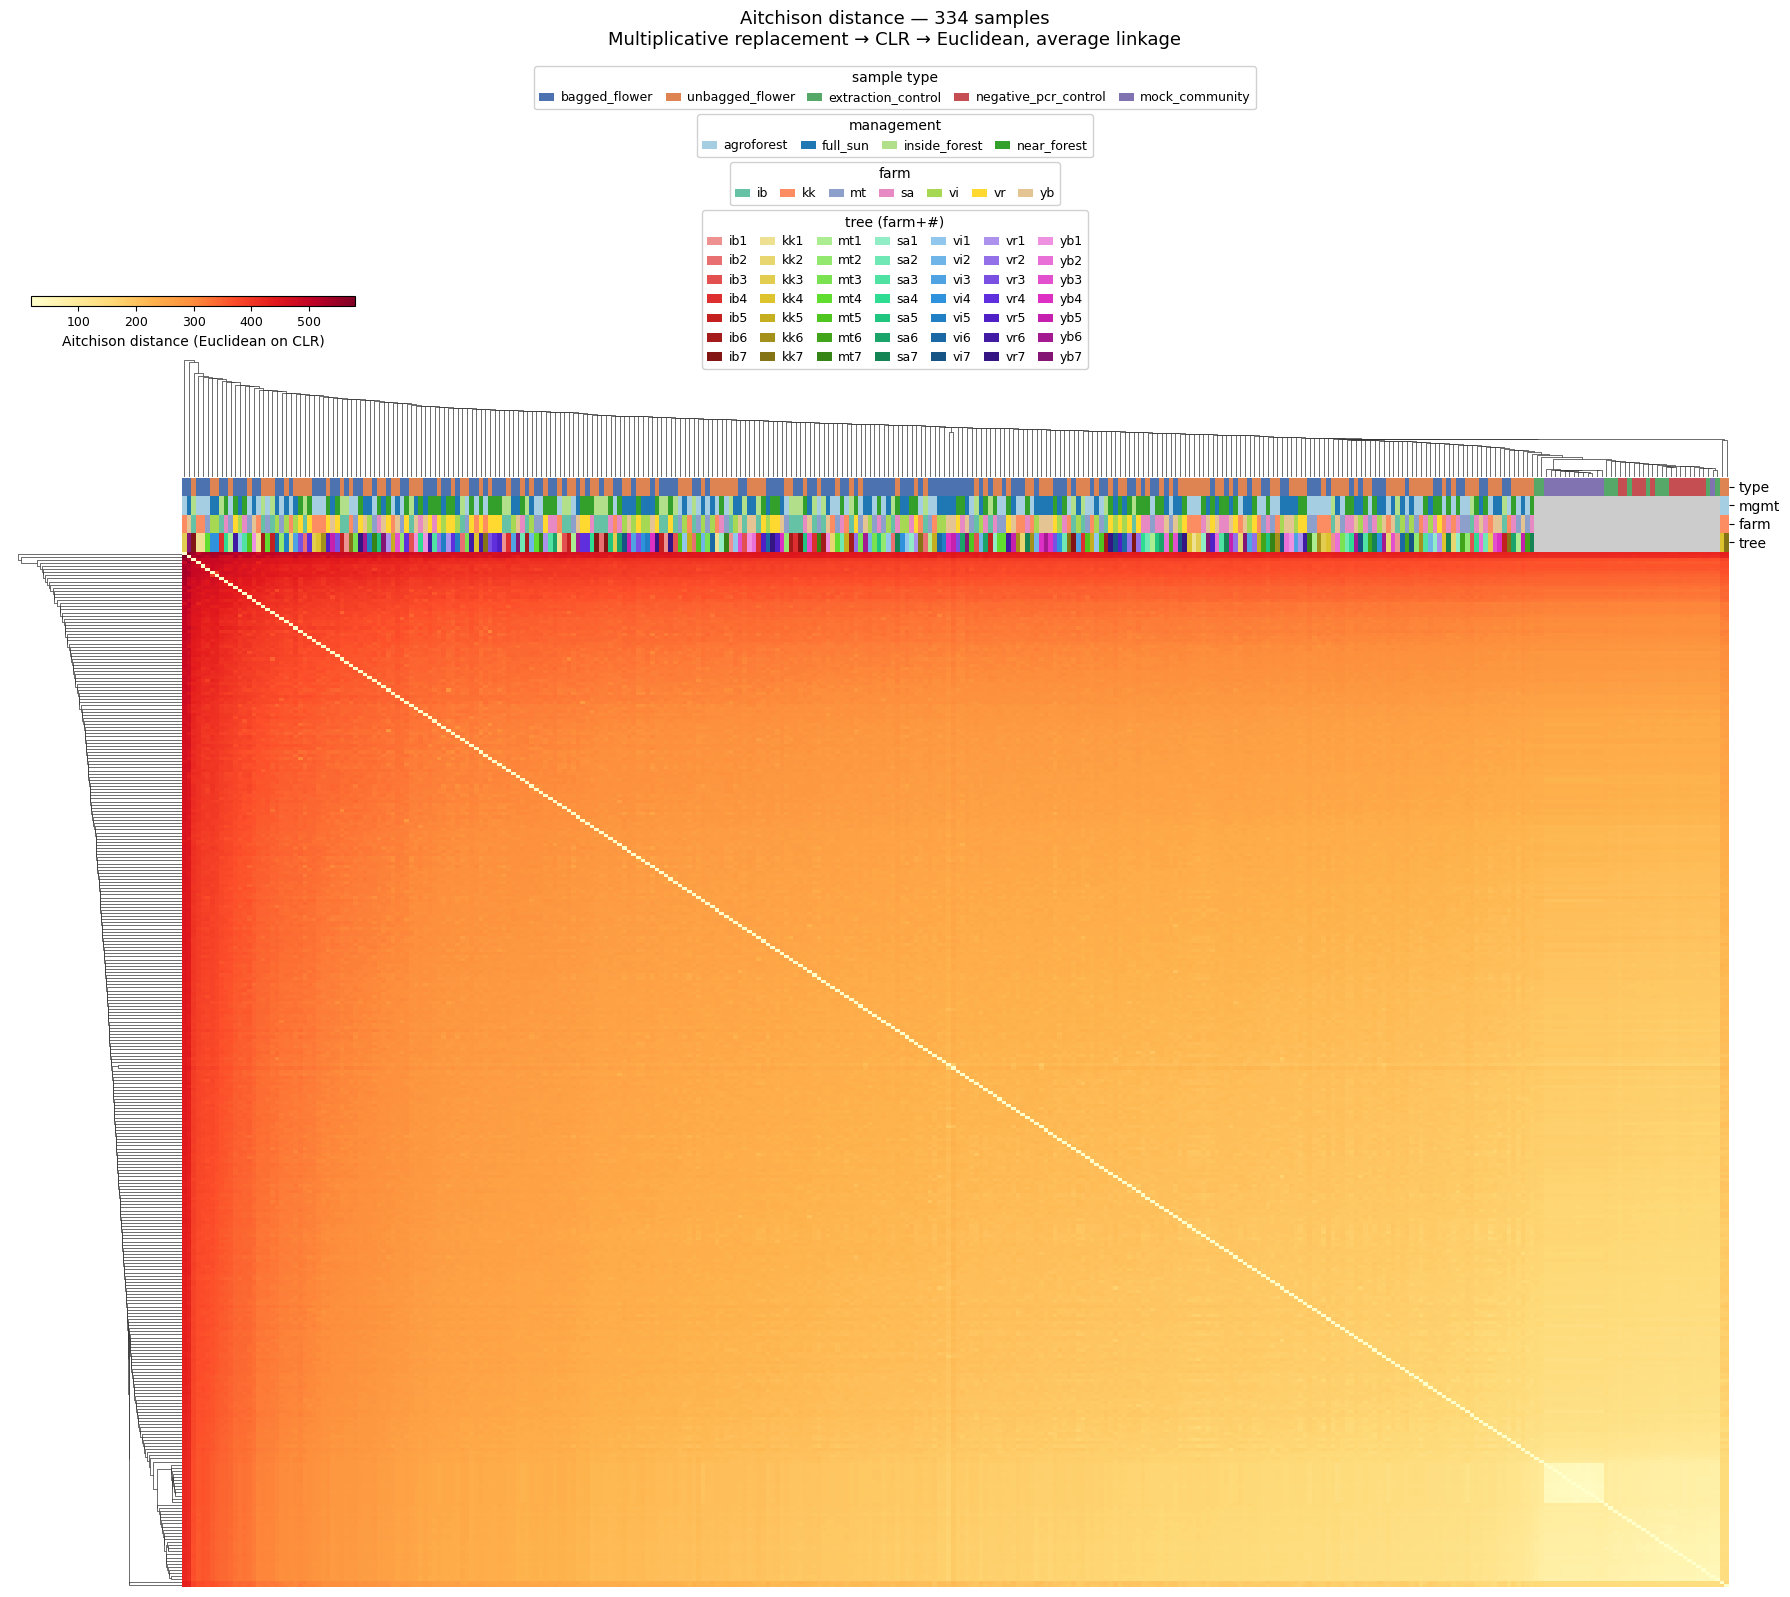

In [62]:
g_ait = sns.clustermap(
    aitchison_df, row_linkage=aitchison_linkage, col_linkage=aitchison_linkage,
    col_colors=row_colors_all,
    figsize=(18, 16), yticklabels=False, xticklabels=False,
    cmap='YlOrRd', cbar_pos=None,
    dendrogram_ratio=(0.10, 0.10), colors_ratio=0.015,
)
g_ait.fig.subplots_adjust(top=0.78)
add_cbar(g_ait.fig, 'YlOrRd',
         mpl.colors.Normalize(vmin=triu_ait.min(), vmax=triu_ait.max()),
         'Aitchison distance (Euclidean on CLR)', pos=(0.02, 0.81, 0.18, 0.006))
g_ait.fig.suptitle(
    f'Aitchison distance \u2014 {len(sample_ids)} samples\n'
    'Multiplicative replacement \u2192 CLR \u2192 Euclidean, average linkage',
    x=0.5, y=0.995, ha='center', fontsize=13)
add_legends(g_ait.fig, y0=0.960)
plt.show()


## PART 2: Comparative panels: 16S vs ITS1 · all vs bio samples

## CLUSTERMAPS: SIMILAR COMMUNITY COMPOSITION PROFILES (for top-50 ASVs by prevalence)
- Log transformed relative abundances (all zeroes substituted by 10-6 for numerical stability)
- Centered-log-ration (CLR) transformed comparisoon witout any filtering

In [75]:
# Build DATASETS from pre-loaded RAW (no re-reading BIOM files)
# NOTE: top-50 ASVs selected from ALL samples (incl. controls) for consistency
#       with the individual 16S all-samples heatmaps.
_DS_KEYS = [
    ('16s_all',  '16S · all',  '16S — all samples'),
    ('16s_bio',  '16S · bio',  '16S — bio only'),
    ('its1_all', 'ITS1 · all', 'ITS1 — all samples'),
    ('its1_bio', 'ITS1 · bio',  'ITS1 — bio only'),
]

def _build_ds(raw_key, label):
    raw   = RAW[raw_key]
    sids  = raw['sids']
    rel   = raw['rel']
    asvs  = list(raw['cnt'].columns)
    meta_ds = metadata_raw.reindex(sids)

    bc_c   = pdist(rel.values, metric='braycurtis')
    bc_m   = squareform(bc_c);  bc_lnk = linkage(bc_c, method='average')

    comp    = multiplicative_replacement(rel.values)
    clr_arr = clr(comp)
    ait_c   = pdist(clr_arr, metric='euclidean')
    ait_m   = squareform(ait_c);  ait_lnk = linkage(ait_c, method='average')

    # top-50 from ALL samples (consistent with individual heatmaps)
    top50 = rel.mean(axis=0).nlargest(50).index

    a2g  = raw['tax']['Taxon'].apply(extract_genus).to_dict()
    graw = [a2g.get(a, 'unclassified') for a in top50]
    _c, rn = {}, {}
    for asv, g in zip(top50, graw):
        if graw.count(g) > 1:
            _c[g] = _c.get(g, 0) + 1;  rn[asv] = f'{g} ({_c[g]})'
        else:
            rn[asv] = g

    log_top  = np.log10(rel[top50] + 1e-6).rename(columns=rn)
    clr_df_  = pd.DataFrame(clr_arr, index=sids, columns=asvs)
    clr_top  = clr_df_[top50].rename(columns=rn)
    log_clnk = linkage(pdist(log_top.T.values, metric='euclidean'), method='average')
    clr_clnk = linkage(pdist(clr_top.T.values, metric='euclidean'), method='average')

    return dict(
        label=label, sids=sids, meta=meta_ds,
        log_top=log_top, clr_top=clr_top,
        log_clnk=log_clnk, clr_clnk=clr_clnk,
        bc_df=pd.DataFrame(bc_m,  index=sids, columns=sids), bc_lnk=bc_lnk,
        ait_df=pd.DataFrame(ait_m, index=sids, columns=sids), ait_lnk=ait_lnk,
        ait_cond=ait_c,
    )

print('Building DATASETS from pre-loaded RAW ...')
DATASETS = {}
for raw_key, lbl, _ in _DS_KEYS:
    print(f'  {lbl} ...', end=' ')
    DATASETS[lbl] = _build_ds(raw_key, lbl)
    d = DATASETS[lbl]
    print(f'{len(d["sids"])} samples x {d["log_top"].shape[1]} top ASVs')

_DS_ORDER  = [lbl for _, lbl, _ in _DS_KEYS]
_DS_TITLES = [ttl for _, _, ttl in _DS_KEYS]
print('Done.')


Building DATASETS from pre-loaded RAW ...
  16S · all ... 334 samples x 50 top ASVs
  16S · bio ... 294 samples x 50 top ASVs
  ITS1 · all ... 326 samples x 50 top ASVs
  ITS1 · bio ... 294 samples x 50 top ASVs
Done.


In [76]:
def _draw_one(fig, spec, ds, mode, title, norm_override=None):
    if mode == 'logra':
        data, rl, cl = ds['log_top'], ds['bc_lnk'], ds['log_clnk']
        cmap = 'YlOrRd'
        norm = norm_override if norm_override is not None else \
               mpl.colors.Normalize(data.values.min(), data.values.max())
        cbl  = 'log\u2081\u2080(RA + 1e-6)';  transpose = True
    elif mode == 'clr':
        data, rl, cl = ds['clr_top'], ds['ait_lnk'], ds['clr_clnk']
        cmap = 'RdBu_r'
        if norm_override is not None:
            norm = norm_override
        else:
            vm   = max(abs(data.values.min()), abs(data.values.max()))
            norm = mpl.colors.TwoSlopeNorm(vmin=-vm, vcenter=0, vmax=vm)
        cbl  = 'CLR value';  transpose = True
    elif mode == 'bc':
        data, rl, cl = ds['bc_df'], ds['bc_lnk'], ds['bc_lnk']
        cmap = 'YlOrRd';  norm = norm_override or mpl.colors.Normalize(0, 1)
        cbl  = 'Bray-Curtis dissimilarity';  transpose = False
    else:  # aitchison
        data, rl, cl = ds['ait_df'], ds['ait_lnk'], ds['ait_lnk']
        tv   = ds['ait_df'].values[np.triu_indices(len(ds['sids']), k=1)]
        cmap = 'YlOrRd';  norm = norm_override or mpl.colors.Normalize(tv.min(), tv.max())
        cbl  = 'Aitchison distance';  transpose = False

    ro = leaves_list(rl);  co = leaves_list(cl)
    dr = data.iloc[ro].iloc[:, co]
    rc = _row_colors4(ds['meta']).iloc[ro]   # sample annotation in row order

    n_strips = len(rc.columns)  # 4
    # Layout: [title] + [n_strips strips] + [heatmap]
    # Height ratios (arbitrary units, converted internally)
    gs = mgs.GridSpecFromSubplotSpec(
        2 + n_strips, 1, subplot_spec=spec,
        height_ratios=[4] + [1.2] * n_strips + [88],
        hspace=0.005,
    )

    # Title
    ax_ttl = fig.add_subplot(gs[0, 0]);  ax_ttl.axis('off')
    ax_ttl.text(0.5, 0.3, title, ha='center', va='center',
                fontsize=9, fontweight='bold', transform=ax_ttl.transAxes)

    # Horizontal annotation strips at top
    # rc is in row order (= column order for transposed logra/clr)
    n_samp = len(rc)
    for j, col_name in enumerate(rc.columns):
        ax_s = fig.add_subplot(gs[j + 1, 0])
        arr  = np.array([[mpl.colors.to_rgb(c) for c in rc[col_name]]])  # (1, n_samples)
        ax_s.imshow(arr, aspect='auto', origin='upper',
                    extent=[0, n_samp, 0, 1], interpolation='none')
        ax_s.set_xticks([]);  ax_s.set_yticks([0.5])
        ax_s.set_yticklabels([col_name], fontsize=6, va='center')
        for sp in ax_s.spines.values():  sp.set_visible(False)

    # Heatmap
    ax_ht = fig.add_subplot(gs[n_strips + 1, 0])
    if transpose:
        data_disp = dr.T   # ASVs x samples
        img = ax_ht.pcolormesh(data_disp.values, cmap=cmap, norm=norm, rasterized=True)
        ax_ht.set_yticks(np.arange(data_disp.shape[0]) + 0.5)
        ax_ht.set_yticklabels(list(data_disp.index), fontsize=5)
        ax_ht.set_xticks([])
        ax_ht.invert_yaxis()
    else:
        img = ax_ht.pcolormesh(dr.values, cmap=cmap, norm=norm, rasterized=True)
        ax_ht.set_yticks([]);  ax_ht.set_xticks([])
        ax_ht.invert_yaxis()

    return img, cmap, norm, cbl


def _draw_legend(ax, shared_cmap=None, shared_norm=None, shared_cbl=None):
    ax.axis('off')
    P = Patch

    if shared_cmap is not None:
        cax = ax.inset_axes([0.15, 0.62, 0.70, 0.28])
        cb  = ax.get_figure().colorbar(
            mpl.cm.ScalarMappable(norm=shared_norm, cmap=shared_cmap),
            cax=cax, orientation='horizontal')
        cb.set_label(shared_cbl or '', fontsize=11)
        cb.ax.tick_params(labelsize=9)
        _y0 = 0.55
    else:
        _y0 = 1.00

    def _leg(handles, title, anchor, ncol, fs=7):
        l = ax.legend(handles=handles, title=title,
                      loc='upper left', bbox_to_anchor=anchor,
                      bbox_transform=ax.transAxes, ncol=ncol,
                      framealpha=0, fontsize=fs, title_fontsize=fs+1,
                      handlelength=1.0, handletextpad=0.4, columnspacing=0.7)
        ax.add_artist(l)

    _dy = 0.18
    _leg([P(fc=c, label=n, lw=0) for n, c in SAMPLE_TYPE_COLORS.items()],
         'sample type', (0.0, _y0),            len(SAMPLE_TYPE_COLORS))
    _leg([P(fc=mpl.colors.to_hex(c), label=n, lw=0) for n, c in MGMT_COLORS.items()]
         + [P(fc=CTRL_COLOR, label='control/NA', lw=0)],
         'management', (0.0, _y0 - _dy),       len(MGMT_COLORS) + 1)
    _leg([P(fc=mpl.colors.to_hex(c), label=n, lw=0) for n, c in farm_palette.items()]
         + [P(fc=CTRL_COLOR, label='control/NA', lw=0)],
         'farm', (0.0, _y0 - 2*_dy),           len(farm_palette) + 1)
    tr_h = [P(fc=mpl.colors.to_hex(tree_palette_49.get(f'{fm}{t}', CTRL_COLOR)),
              label=f'{fm}{t}', lw=0)
            for fm in farm_ids_uniq for t in range(1, 8)]
    tr_h += [P(fc=CTRL_COLOR, label='control/NA', lw=0)]
    _leg(tr_h, 'tree (farm+#)', (0.0, _y0 - 3*_dy), 8, fs=6)


print('Helpers ready.')


Helpers ready.


### Panel 1 — Relative abundance (log₁₀ RA + 1e-6) · top-50 ASVs

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_01_logra.png


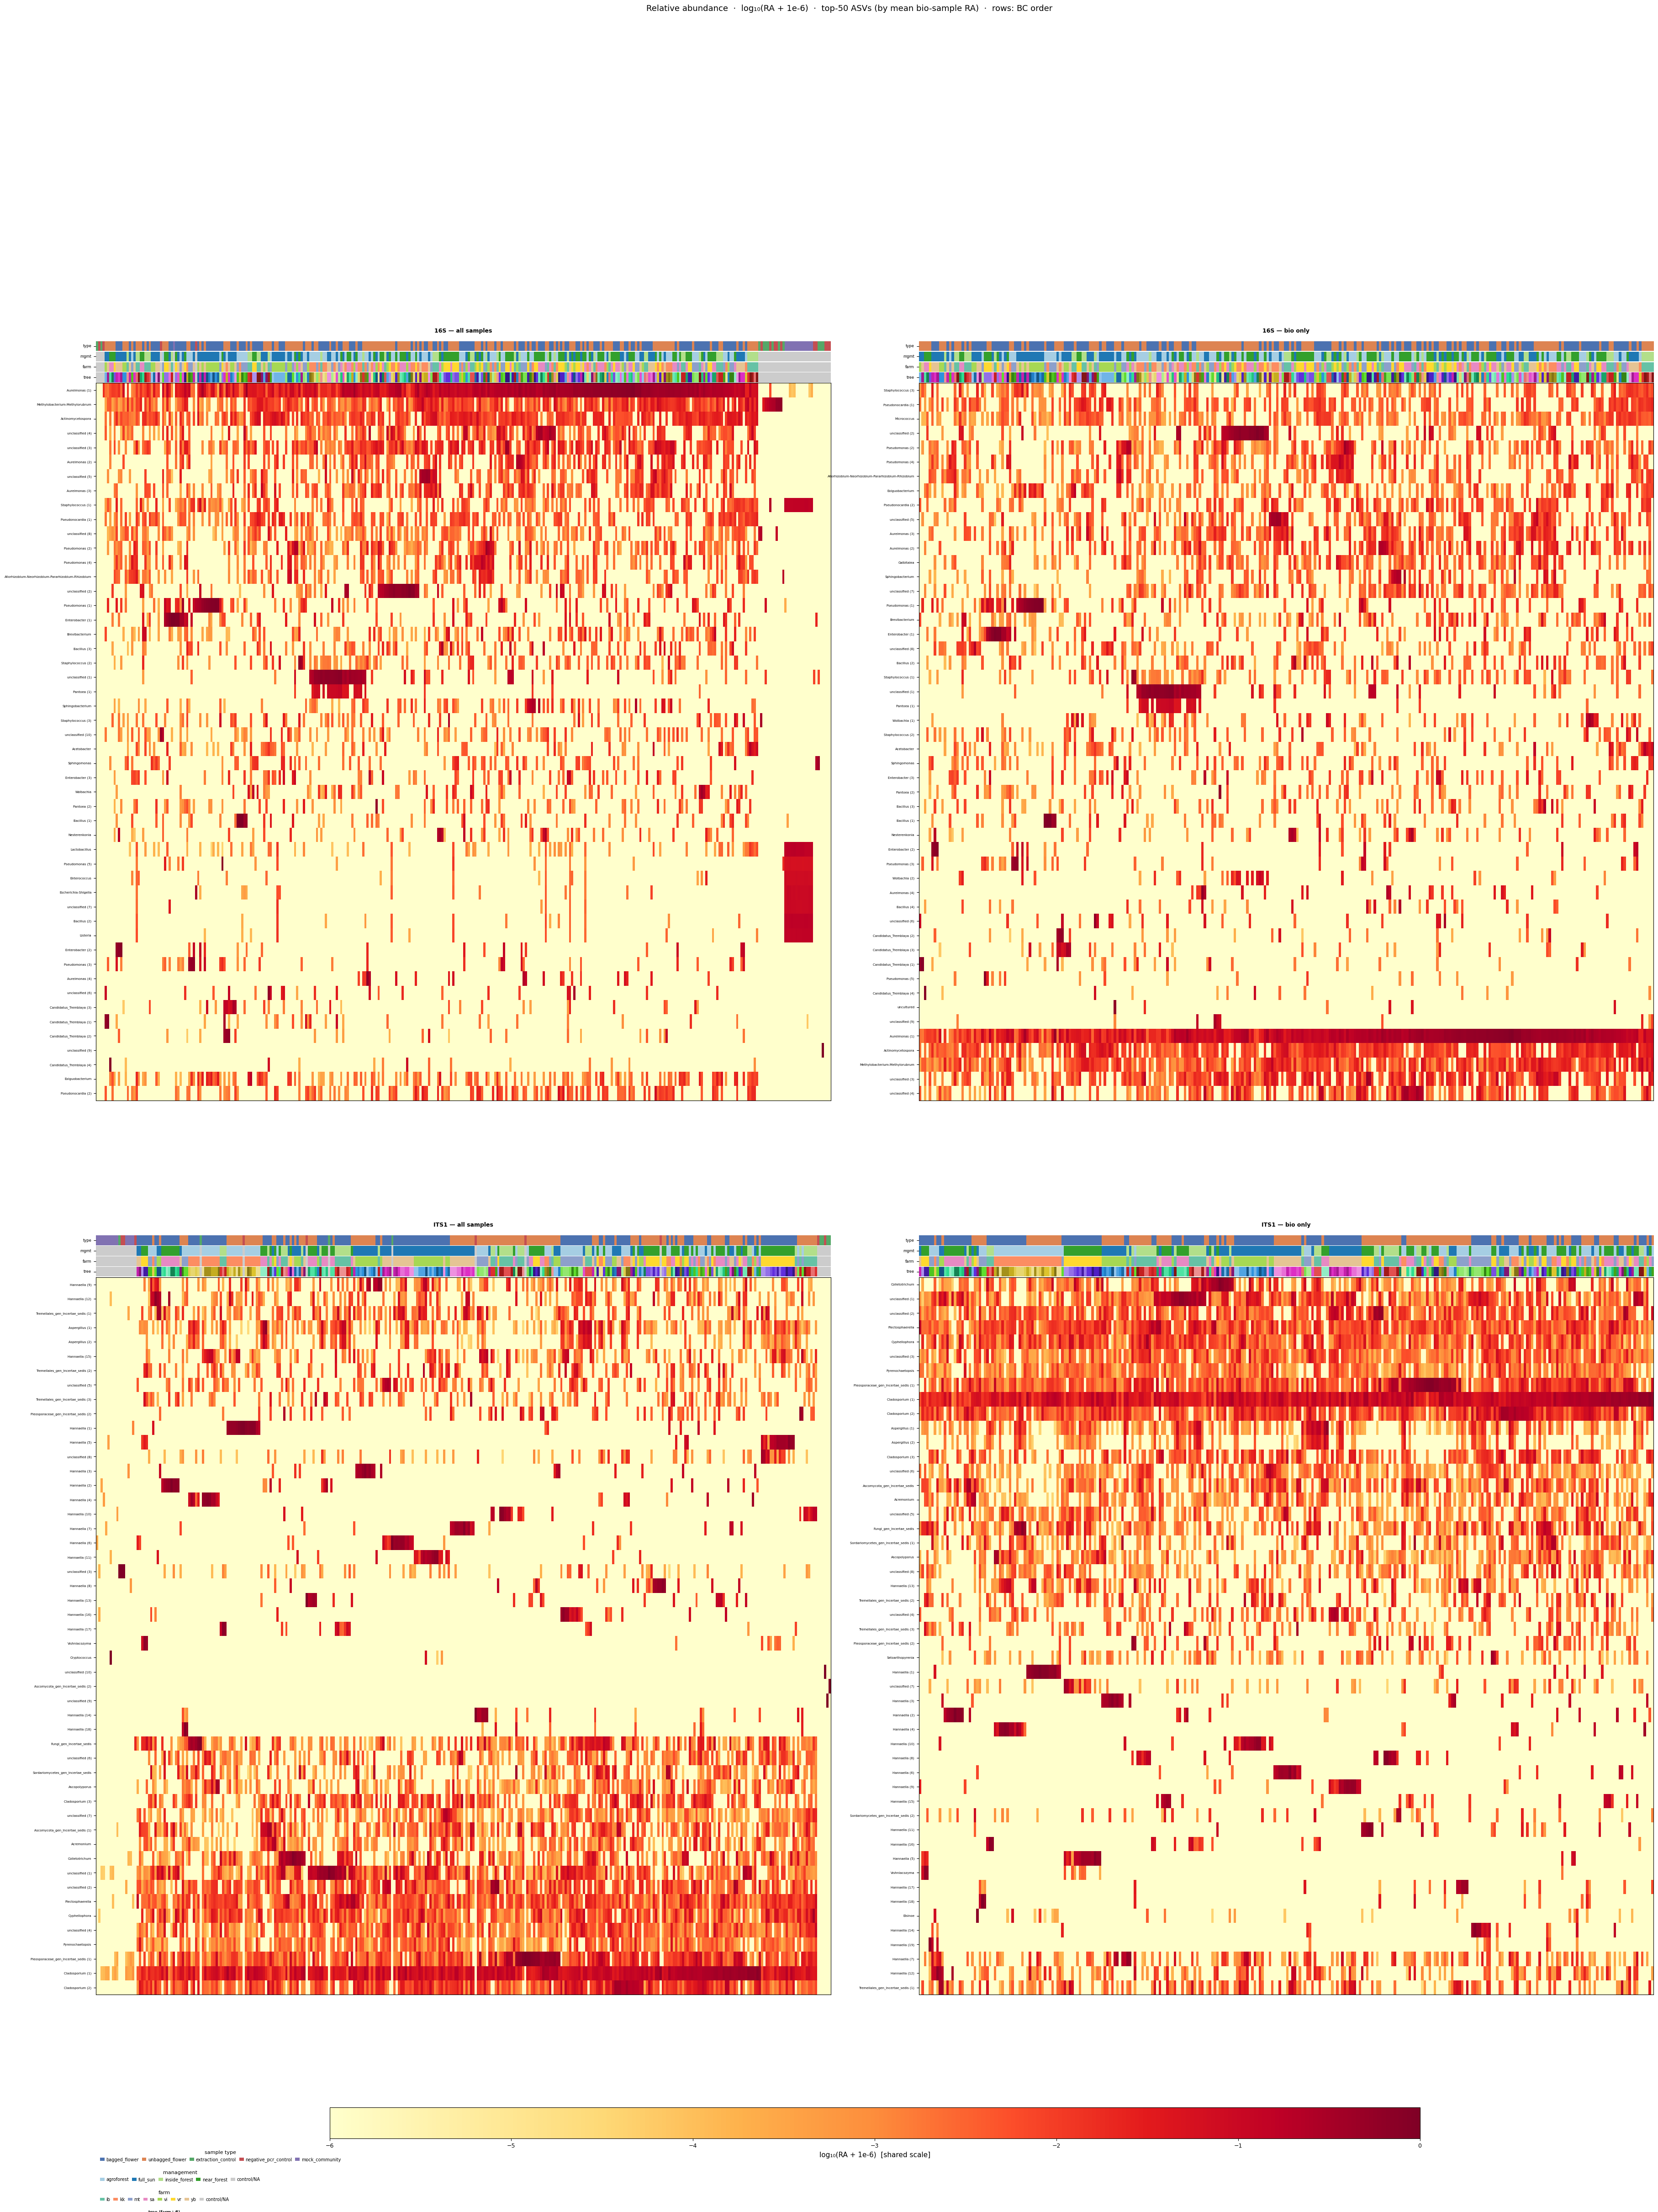

In [77]:
# Global norm: full value range across all 4 datasets for this mode
_all_log = np.concatenate([DATASETS[l]["log_top"].values.ravel() for l in _DS_ORDER])
_global_norm = mpl.colors.Normalize(_all_log.min(), _all_log.max())
_global_cmap = "YlOrRd"
_global_cbl  = "log\u2081\u2080(RA + 1e-6)  [shared scale]"

_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "logra", _ttl,
              norm_override=_global_norm)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg, shared_cmap=_global_cmap,
             shared_norm=_global_norm, shared_cbl=_global_cbl)

_fig.suptitle("Relative abundance  \u00b7  log\u2081\u2080(RA + 1e-6)  \u00b7  top-50 ASVs (by mean bio-sample RA)  \u00b7  rows: BC order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_01_logra.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()


### Panel 2 — CLR-transformed abundance · top-50 ASVs

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_02_clr.png


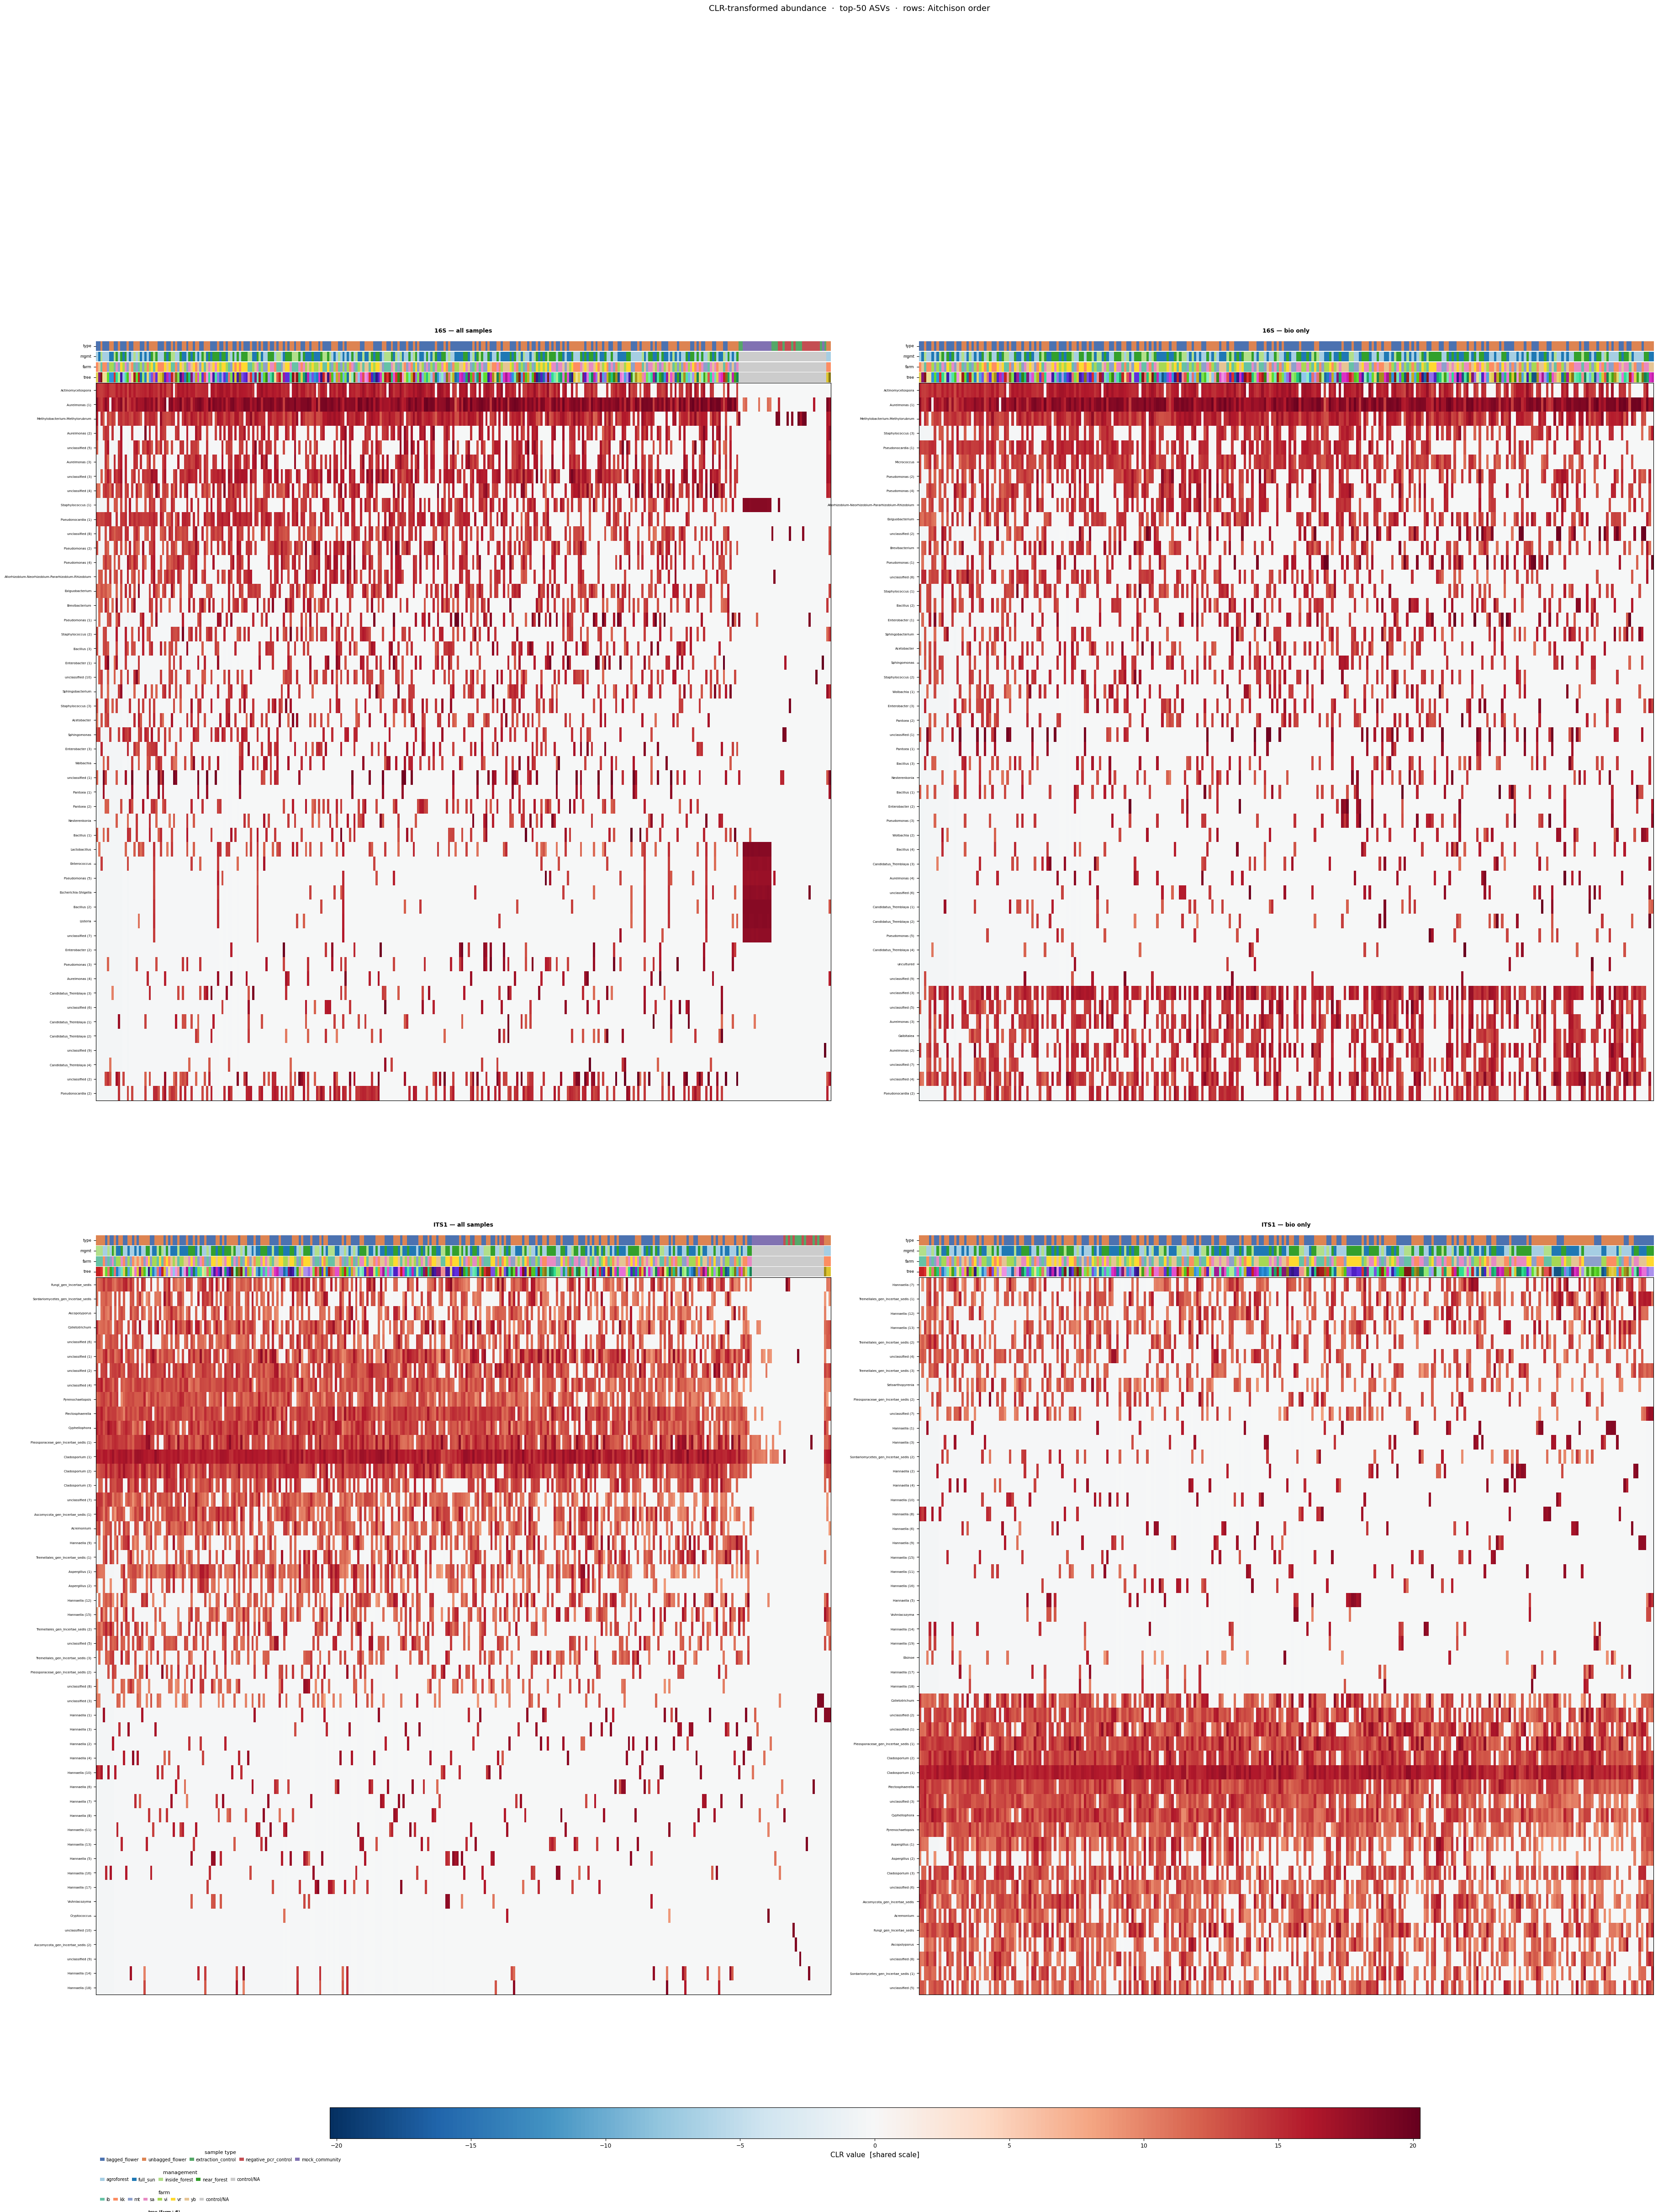

In [78]:
# Global symmetric norm: largest absolute CLR value across all 4 datasets
_all_clr = np.concatenate([DATASETS[l]["clr_top"].values.ravel() for l in _DS_ORDER])
_vm = max(abs(_all_clr.min()), abs(_all_clr.max()))
_global_norm = mpl.colors.TwoSlopeNorm(vmin=-_vm, vcenter=0, vmax=_vm)
_global_cmap = "RdBu_r"
_global_cbl  = "CLR value  [shared scale]"

_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "clr", _ttl,
              norm_override=_global_norm)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg, shared_cmap=_global_cmap,
             shared_norm=_global_norm, shared_cbl=_global_cbl)

_fig.suptitle("CLR-transformed abundance  \u00b7  top-50 ASVs  \u00b7  rows: Aitchison order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_02_clr.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()


## DISTANCES BETWEEN SAMPLES (pairwise comparison)
- Bray-Curtis dissimilarity
- Euclidian distance on CLR transformed feature table (aka Aitchinson distance)

### Panel 3 — Bray-Curtis dissimilarity matrix

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_03_bc.png


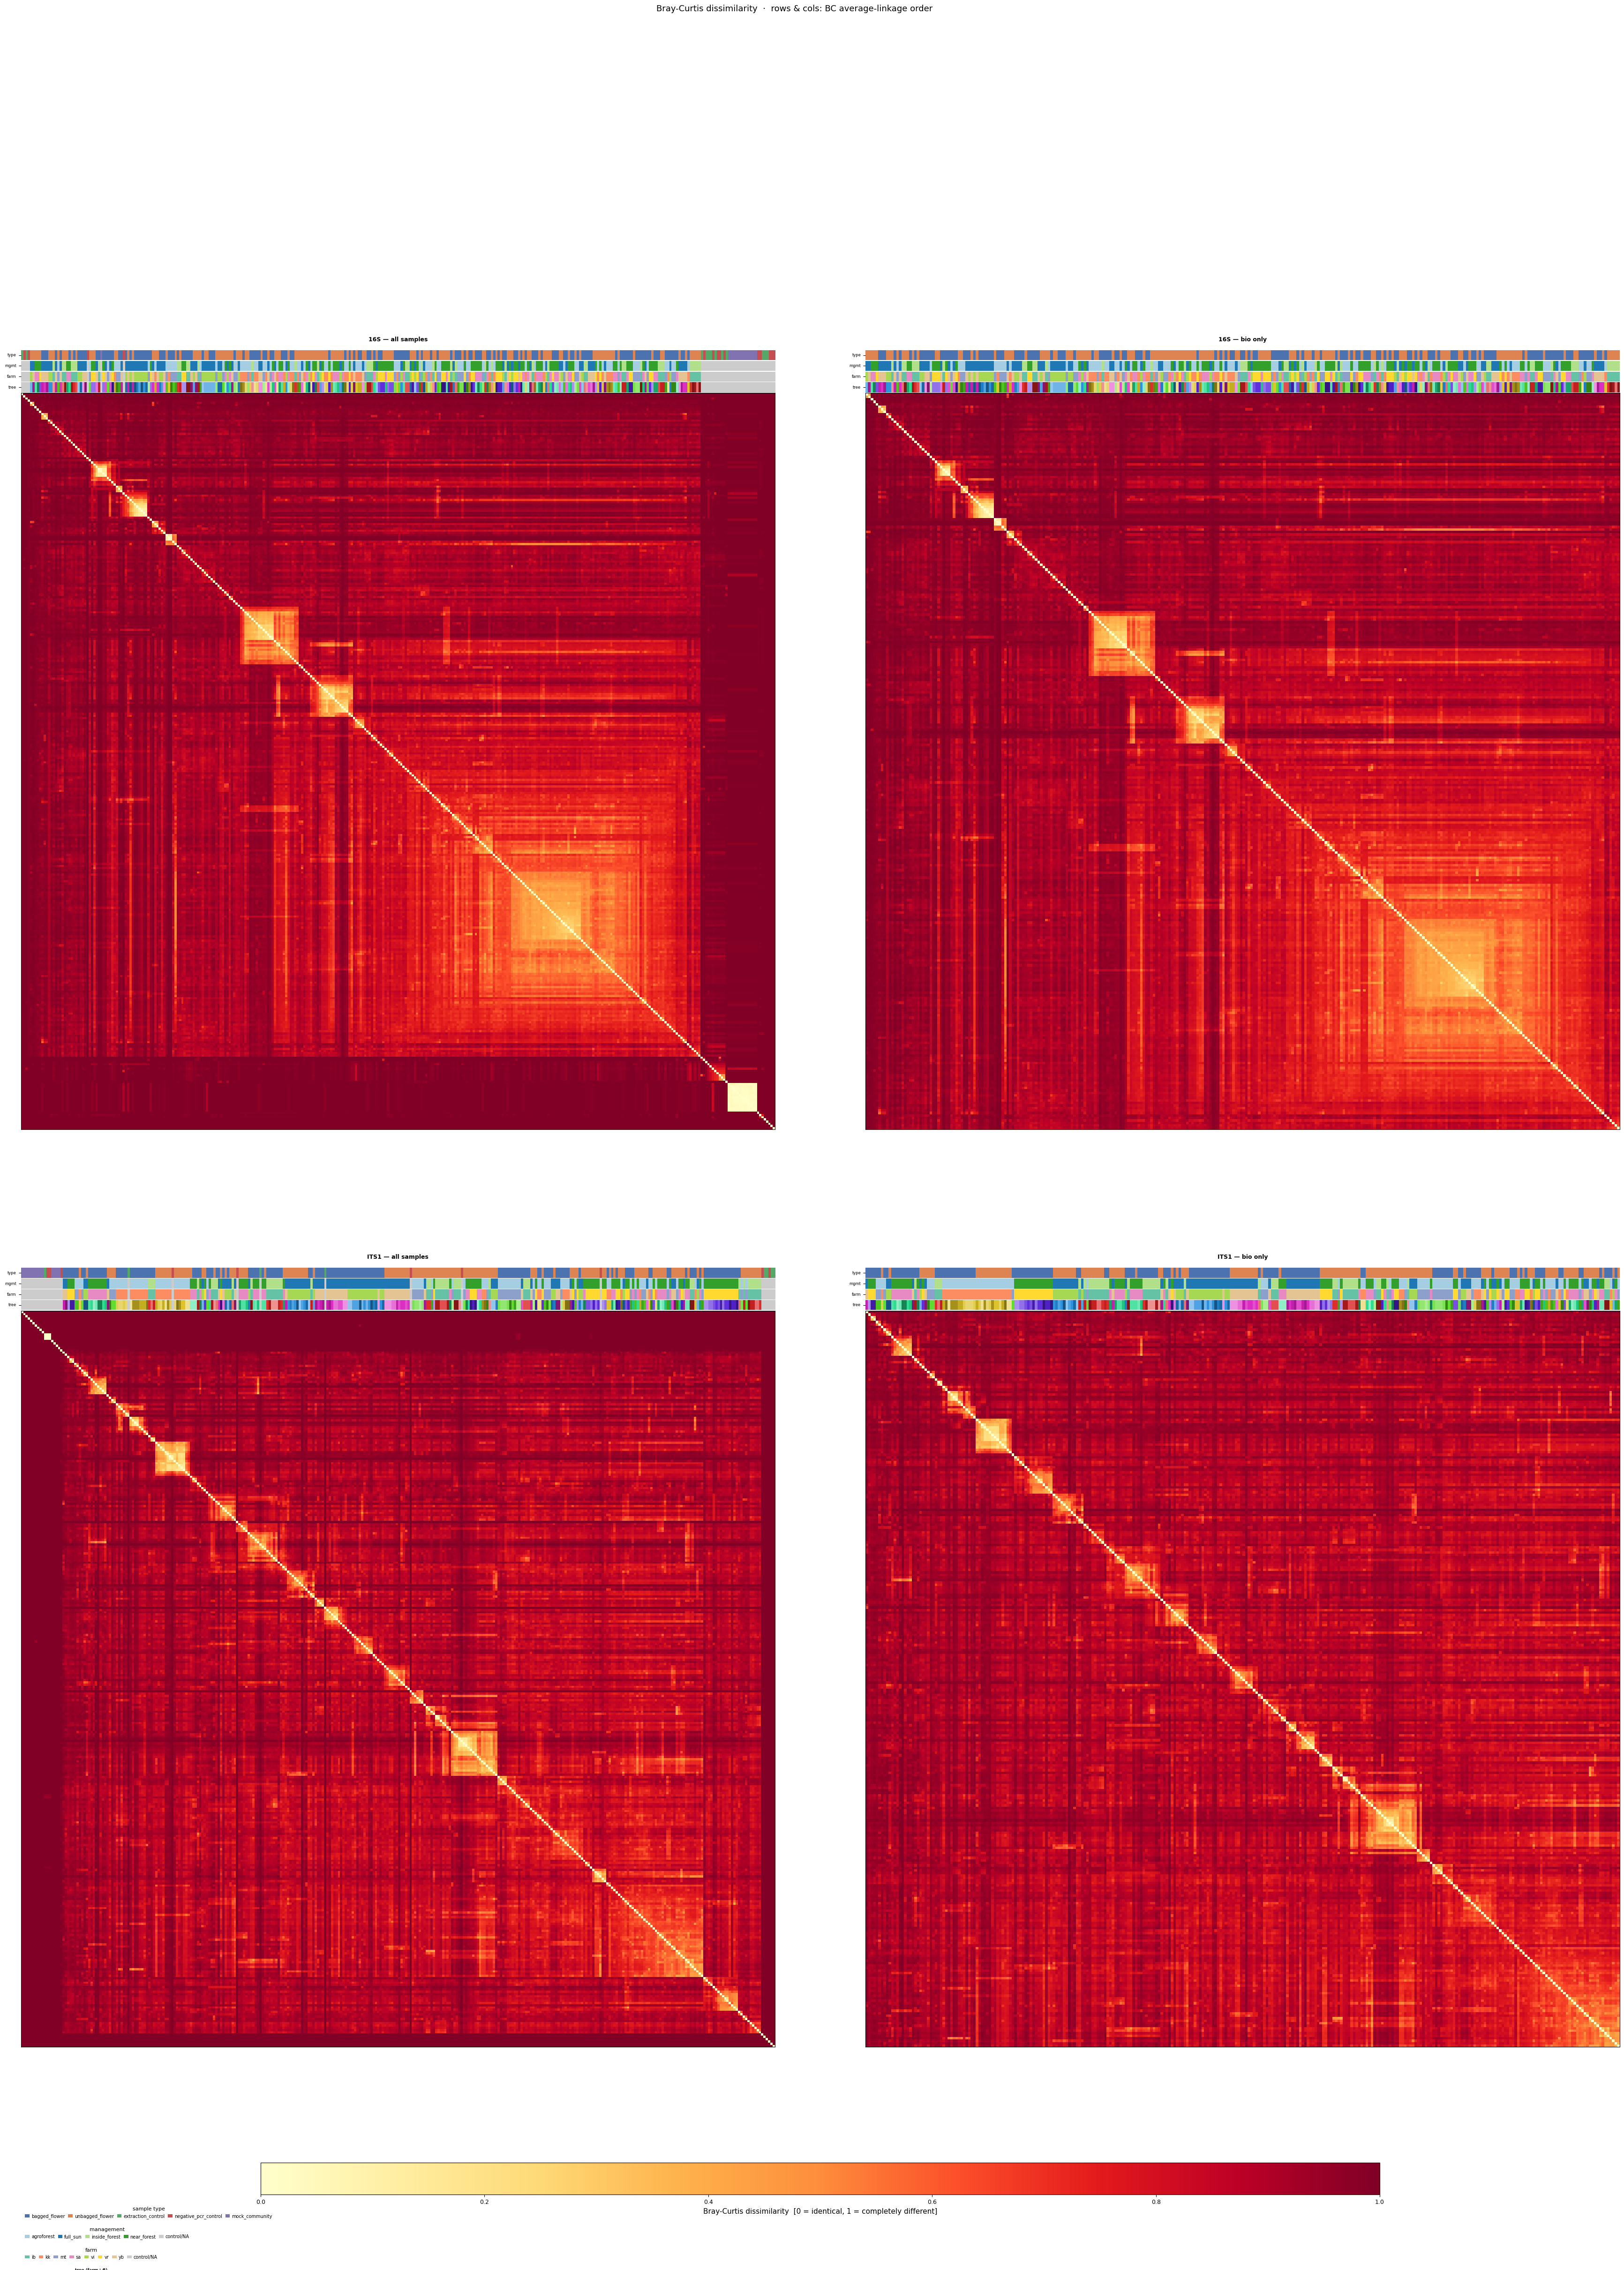

In [79]:
# BC is always [0, 1] -- single norm trivially shared
_global_norm = mpl.colors.Normalize(0, 1)
_global_cmap = "YlOrRd"
_global_cbl  = "Bray-Curtis dissimilarity  [0 = identical, 1 = completely different]"

_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "bc", _ttl,
              norm_override=_global_norm)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg, shared_cmap=_global_cmap,
             shared_norm=_global_norm, shared_cbl=_global_cbl)

_fig.suptitle("Bray-Curtis dissimilarity  \u00b7  rows & cols: BC average-linkage order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_03_bc.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()


### Panel 4 — Aitchison distance matrix

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_04_aitchison.png


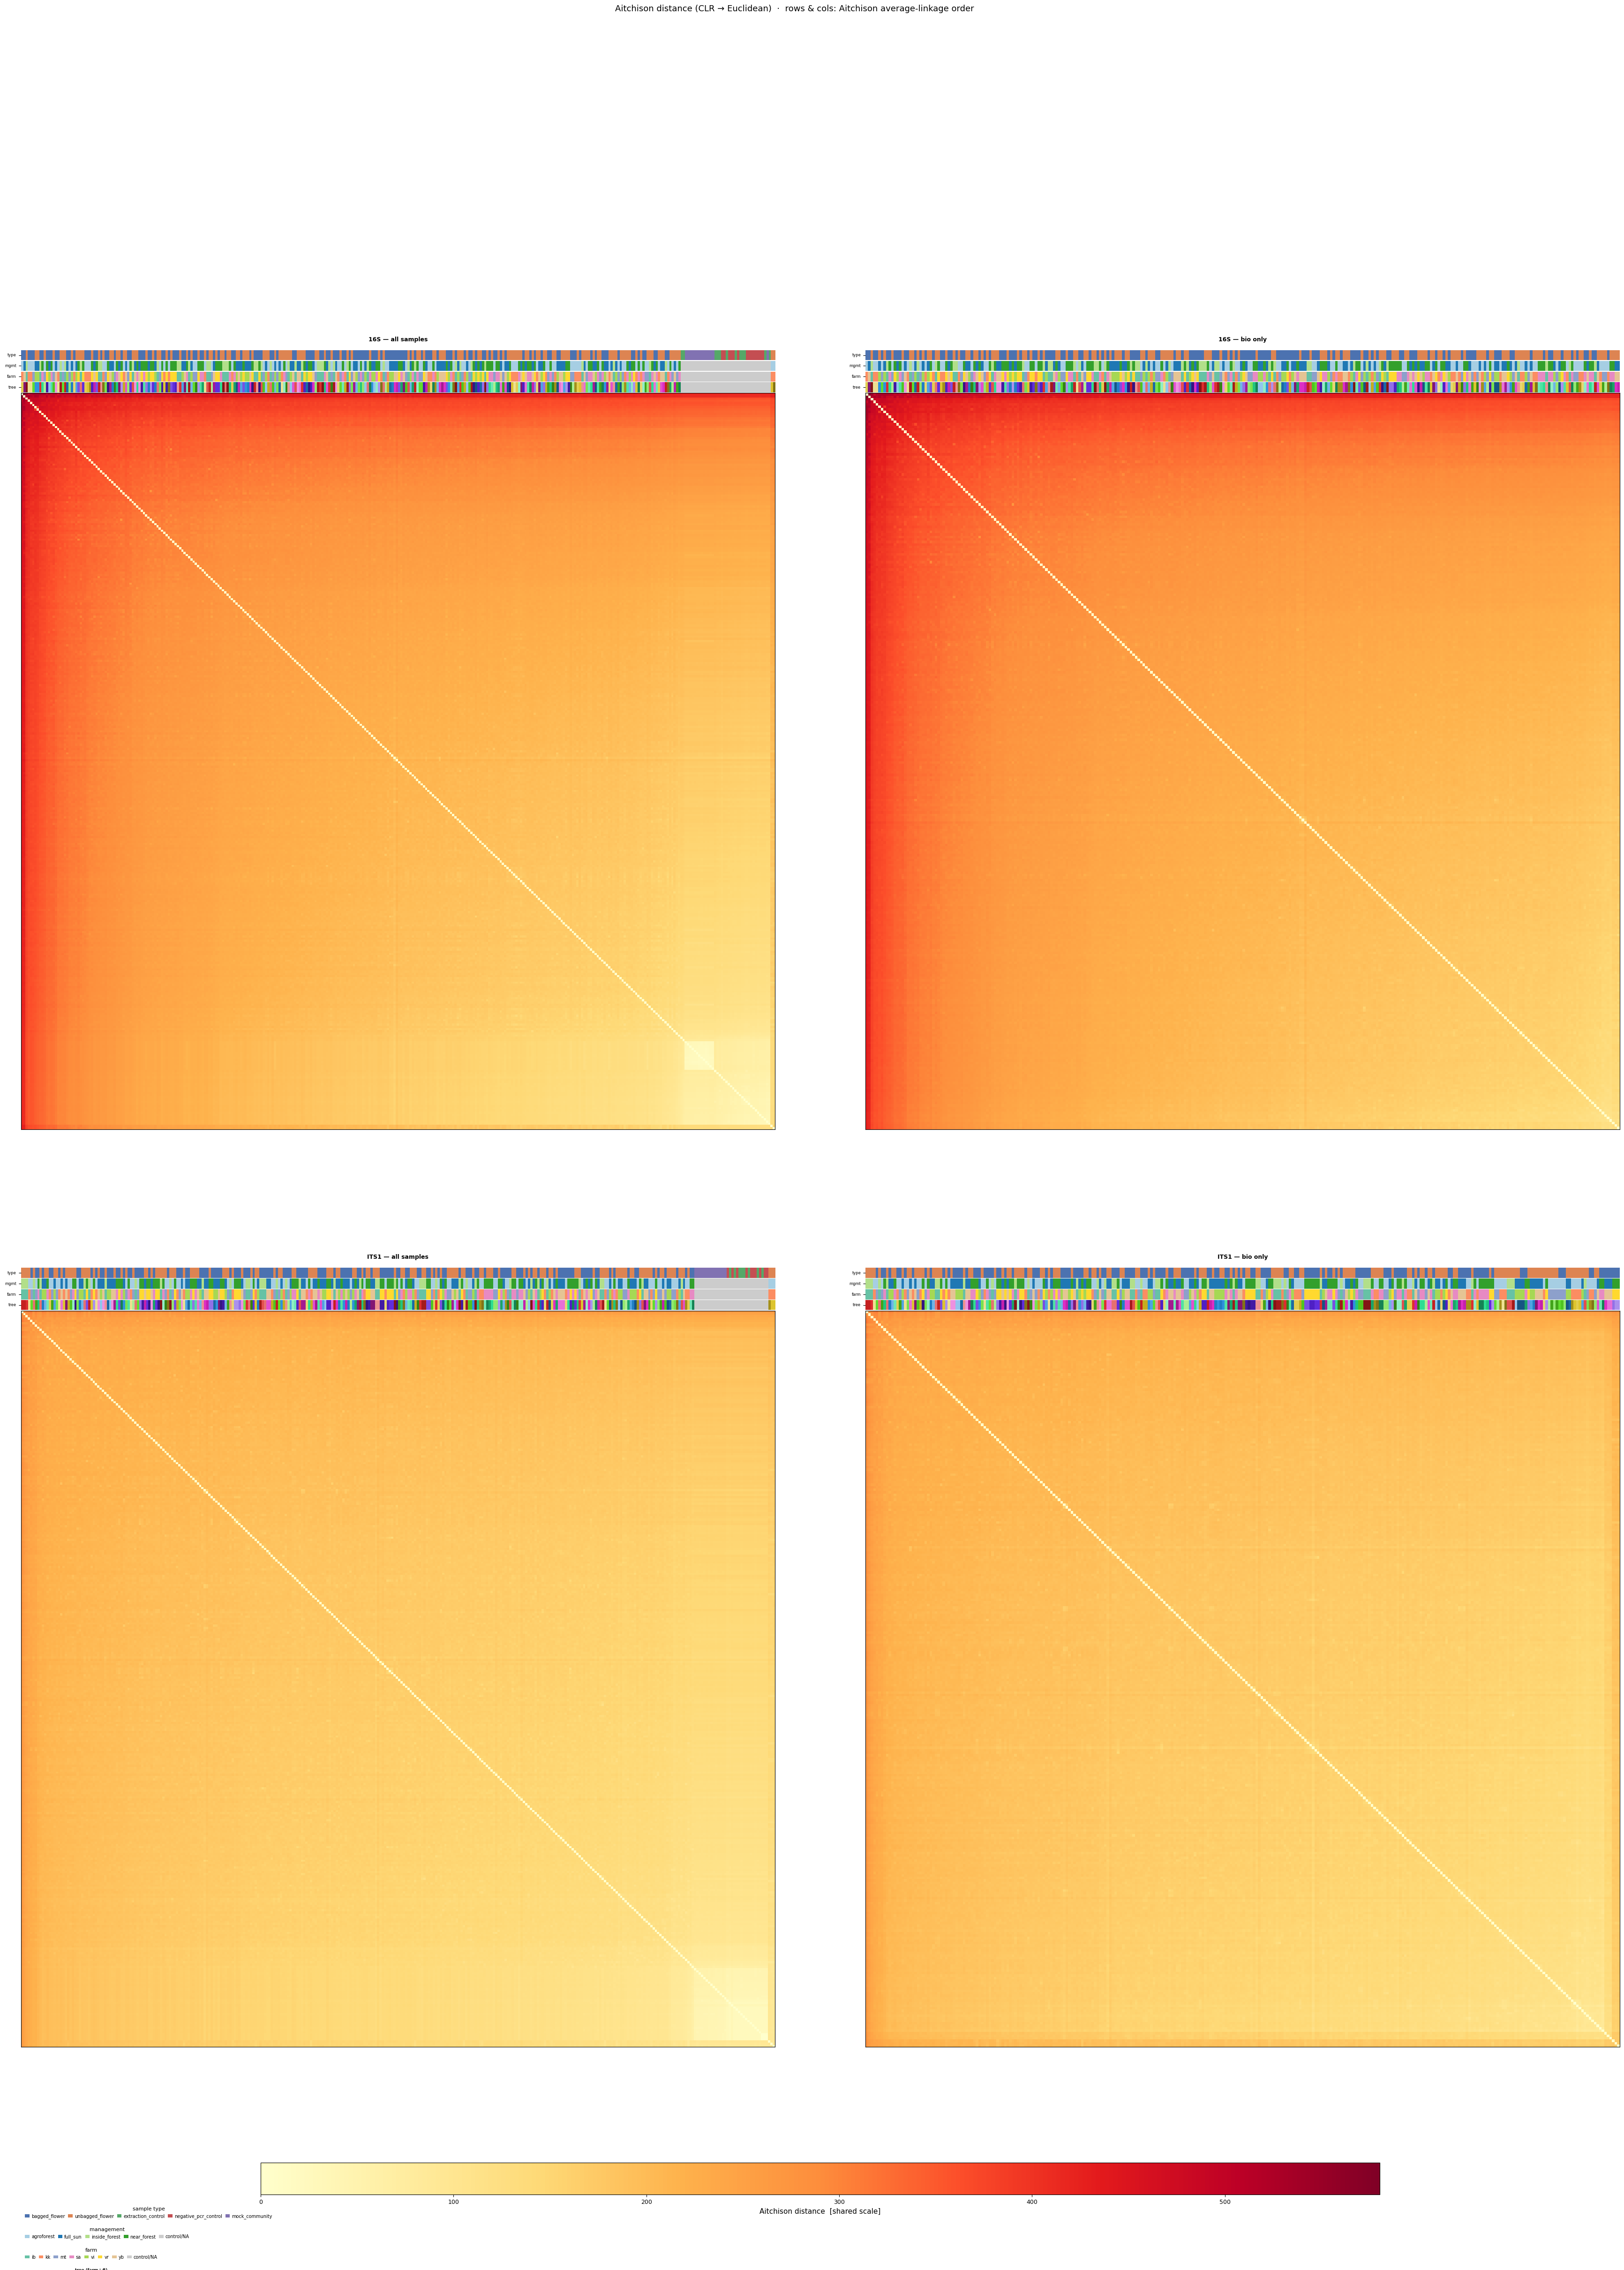

In [68]:
# Global norm: Aitchison distance range across all 4 datasets
_all_ait = np.concatenate([
    DATASETS[l]["ait_df"].values[np.triu_indices(len(DATASETS[l]["sids"]), k=1)]
    for l in _DS_ORDER
])
_global_norm = mpl.colors.Normalize(_all_ait.min(), _all_ait.max())
_global_cmap = "YlOrRd"
_global_cbl  = "Aitchison distance  [shared scale]"

_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _draw_one(_fig, _outer[_r, _c], DATASETS[_lbl], "aitchison", _ttl,
              norm_override=_global_norm)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg, shared_cmap=_global_cmap,
             shared_norm=_global_norm, shared_cbl=_global_cbl)

_fig.suptitle("Aitchison distance (CLR \u2192 Euclidean)  \u00b7  rows & cols: Aitchison average-linkage order", fontsize=13, y=1.003)
_out = PROJECT_ROOT / "results" / "figures" / "panel_04_aitchison.png"
_fig.savefig(_out, dpi=130, bbox_inches="tight")
print(f"Saved: {_out}")
plt.show()


## Filtered ASVs: Aitchison distance clustermap

Filter each dataset to keep only ASVs that are:
- present in **≥5% of samples** (prevalence filter)
- with **total abundance ≥10 reads** across all samples

After filtering, apply multiplicative replacement and CLR, then compute Aitchison distances. This reduces the number of zero-replacements and should make ITS1 cluster structure more visible compared to unfiltered CLR.

In [69]:
def filter_asvs(cnt, min_prev=0.05, min_abund=10):
    prev = (cnt > 0).mean(axis=0)          # fraction of samples with count > 0
    tot  = cnt.sum(axis=0)                  # total reads per ASV
    keep = (prev >= min_prev) & (tot >= min_abund)
    return cnt.loc[:, keep]

print(f'Filtering: prevalence >= 5%,  total abundance >= 10')
print(f'{"Dataset":20s}  {"ASVs before":>12}  {"ASVs after":>10}  {"kept %":>7}  {"samples dropped":>15}')
print('-' * 75)

DATASETS_FILT = {}
for raw_key, lbl, ttl in _DS_KEYS:
    raw   = RAW[raw_key]
    cnt_f = filter_asvs(raw['cnt'])

    # Drop samples that have zero total counts after ASV filtering
    # (e.g. mock community samples whose ASVs were removed by prevalence filter).
    # Such samples would produce NaN in relative abundance → clr() fails.
    zero_mask = cnt_f.sum(axis=1) == 0
    n_dropped = int(zero_mask.sum())
    if n_dropped:
        print(f'  [{lbl}] dropping {n_dropped} sample(s) with 0 reads after filter: '
              f'{list(cnt_f.index[zero_mask])}')
    cnt_f = cnt_f.loc[~zero_mask]
    sids_f = list(cnt_f.index)

    pct   = 100 * cnt_f.shape[1] / raw['cnt'].shape[1]
    print(f'{lbl:20s}  {raw["cnt"].shape[1]:>12d}  {cnt_f.shape[1]:>10d}  {pct:>6.1f}%  {n_dropped:>15d}')

    rel_f     = cnt_f.div(cnt_f.sum(axis=1), axis=0)
    comp_f    = multiplicative_replacement(rel_f.values)
    clr_f     = clr(comp_f)
    ait_c_f   = pdist(clr_f, metric='euclidean')
    ait_m_f   = squareform(ait_c_f)
    ait_lnk_f = linkage(ait_c_f, method='average')

    meta_ds = metadata_raw.reindex(sids_f)
    DATASETS_FILT[lbl] = dict(
        label=lbl, sids=sids_f, meta=meta_ds,
        ait_df=pd.DataFrame(ait_m_f, index=sids_f, columns=sids_f),
        ait_lnk=ait_lnk_f,
        n_orig=raw['cnt'].shape[1], n_filt=cnt_f.shape[1],
    )
print('Done.')


Filtering: prevalence >= 5%,  total abundance >= 10
Dataset                ASVs before  ASVs after   kept %  samples dropped
---------------------------------------------------------------------------
  [16S · all] dropping 5 sample(s) with 0 reads after filter: [np.str_('cviNC'), np.str_('cybNC'), np.str_('pibNC'), np.str_('pkkEC'), np.str_('psaEC')]
16S · all                    25035         499     2.0%                5
16S · bio                    25035         580     2.3%                0
  [ITS1 · all] dropping 6 sample(s) with 0 reads after filter: [np.str_('cmtEC'), np.str_('cvrEC'), np.str_('cvrNC'), np.str_('pmtEC'), np.str_('pybEC'), np.str_('pybNC')]
ITS1 · all                   11929         464     3.9%                6
ITS1 · bio                   11929         540     4.5%                0
Done.


Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/panel_05_aitchison_filtered.png


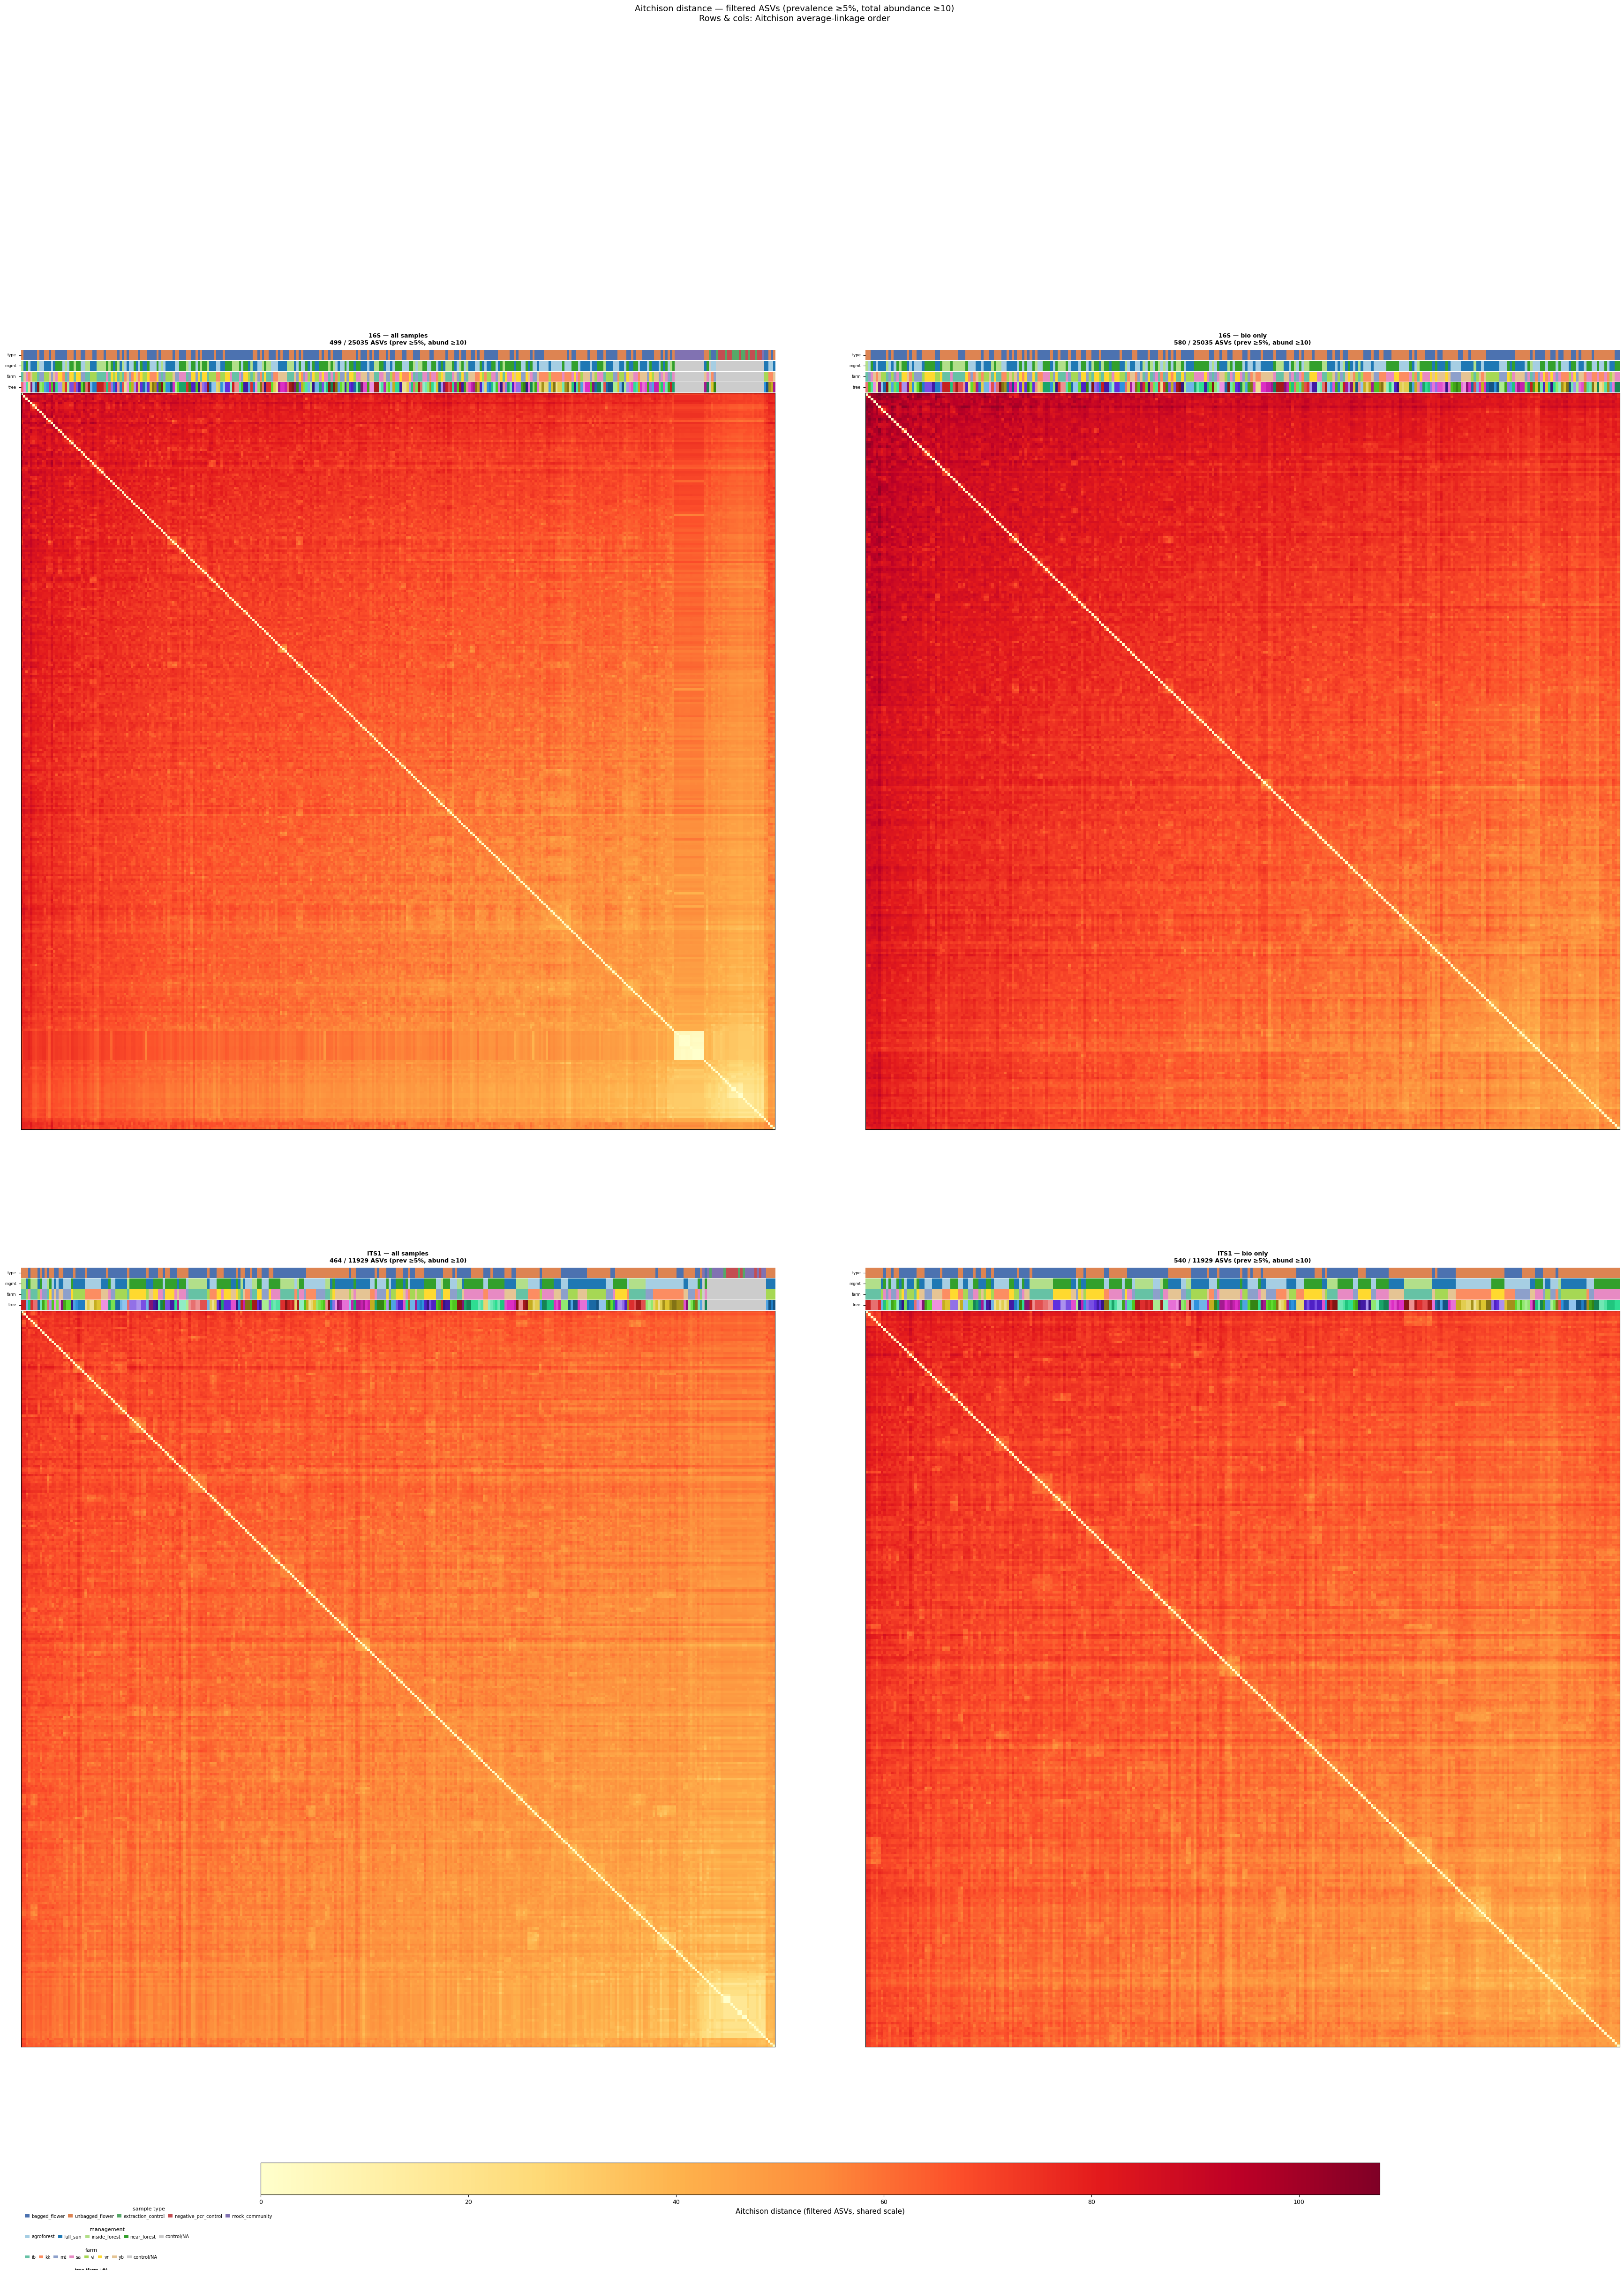

In [70]:
# Shared global norm across all 4 filtered Aitchison matrices
_all_ait_f = np.concatenate([
    DATASETS_FILT[l]['ait_df'].values[
        np.triu_indices(len(DATASETS_FILT[l]['sids']), k=1)]
    for l in _DS_ORDER
])
_norm_filt = mpl.colors.Normalize(_all_ait_f.min(), _all_ait_f.max())

_fig = plt.figure(figsize=(44, 54))
_outer = mgs.GridSpec(3, 2, figure=_fig,
                      height_ratios=[1, 1, 0.14],
                      hspace=0.18, wspace=0.12)

for _idx, (_lbl, _ttl) in enumerate(zip(_DS_ORDER, _DS_TITLES)):
    _r, _c = divmod(_idx, 2)
    _ds_f  = DATASETS_FILT[_lbl]
    _ttl_f = (f'{_ttl}\n'
              f'{_ds_f["n_filt"]} / {_ds_f["n_orig"]} ASVs '
              f'(prev ≥5%, abund ≥10)')
    _draw_one(_fig, _outer[_r, _c], _ds_f, 'aitchison', _ttl_f,
              norm_override=_norm_filt)

_ax_leg = _fig.add_subplot(_outer[2, :])
_draw_legend(_ax_leg,
             shared_cmap='YlOrRd', shared_norm=_norm_filt,
             shared_cbl='Aitchison distance (filtered ASVs, shared scale)')

_fig.suptitle(
    'Aitchison distance — filtered ASVs (prevalence ≥5%, total abundance ≥10)\n'
    'Rows & cols: Aitchison average-linkage order',
    fontsize=13, y=1.003)
_out = PROJECT_ROOT / 'results' / 'figures' / 'panel_05_aitchison_filtered.png'
_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(_out, dpi=130, bbox_inches='tight')
print(f'Saved: {_out}')
plt.show()
